# Story 1: "The Year Nature Went Wild" 🌪️


## Section 1: Setup and Data Loading

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from pandas import Timedelta as timedelta
import warnings
warnings.filterwarnings('ignore')
from matplotlib.ticker import FuncFormatter

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)

# Color scheme
COLORS = {
    'MCO': '#3498db',      # Blue
    'MIA': '#e74c3c',      # Red
    'Cancellations': '#e74c3c',  # Red
    'WeatherDelay': '#f39c12',   # Orange
    'Hurricane': '#2c3e50'       # Dark gray
}

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [2]:
# Create visualizations directory
import os
viz_dir = os.path.join('..', 'visualizations')
os.makedirs(viz_dir, exist_ok=True)
print(f"✓ Visualization directory ready: {viz_dir}")

# Load main flight data
print("Loading flight data...")
df = pd.read_csv('../data/processed/mco_mia_clean.csv.gz',
                  parse_dates=['FlightDate'],
                  compression='gzip')

print(f"Loaded {len(df):,} flight records")
print(f"Date range: {df['FlightDate'].min()} to {df['FlightDate'].max()}")
print(f"Columns: {df.columns.tolist()}")

# Load hurricane data
print("Loading hurricane data...")
hurricanes = pd.read_csv('../data/external/hurricanes_2004_2008.csv',
                          parse_dates=['Date'])

print(f"\nLoaded {len(hurricanes)} hurricane events:")
print(hurricanes[['Date', 'HurricaneName', 'Category', 'PrimaryAirport']].to_string(index=False))


✓ Visualization directory ready: ../visualizations
Loading flight data...
Loaded 1,592,198 flight records
Date range: 2004-01-01 00:00:00 to 2008-04-30 00:00:00
Columns: ['Year', 'Month', 'DayofMonth', 'DayOfWeek', 'DepTime', 'CRSDepTime', 'ArrTime', 'CRSArrTime', 'UniqueCarrier', 'FlightNum', 'TailNum', 'ActualElapsedTime', 'CRSElapsedTime', 'AirTime', 'ArrDelay', 'DepDelay', 'Origin', 'Dest', 'Distance', 'TaxiIn', 'TaxiOut', 'Cancelled', 'CancellationCode', 'Diverted', 'CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay', 'FlightDate', 'CRSDepTime_Hour', 'CRSDepTime_Min', 'DepTime_Hour', 'DepTime_Min', 'CRSArrTime_Hour', 'CRSArrTime_Min', 'ArrTime_Hour', 'ArrTime_Min', 'OnTime', 'DelayCategory', 'Quarter', 'IsHolidaySeason', 'DayName', 'IsMCO', 'IsMIA', 'MCO_Direction', 'MIA_Direction', 'TimeOfDay', 'IsWeekend', 'DistanceCategory', 'Season', 'PrimaryDelayCause']
Loading hurricane data...

Loaded 8 hurricane events:
      Date HurricaneName  Category Primar

## Section 2: Helper Functions

In [3]:
def create_daily_aggregation(df, airport_filter=None, add_rolling_avg=False):
    """Create daily flight statistics with optional airport filtering."""
    if airport_filter == 'MCO':
        data = df[df['IsMCO']].copy()
    elif airport_filter == 'MIA':
        data = df[df['IsMIA']].copy()
    else:
        data = df.copy()
    
    daily_stats = data.groupby('FlightDate').agg({
        'FlightNum': 'count', 'Cancelled': 'sum', 'WeatherDelay': 'mean',
        'CarrierDelay': 'mean', 'LateAircraftDelay': 'mean',
        'NASDelay': 'mean', 'ArrDelay': 'mean'
    }).reset_index()
    
    daily_stats.rename(columns={'FlightNum': 'TotalFlights'}, inplace=True)
    daily_stats['CancellationRate'] = daily_stats['Cancelled'] / daily_stats['TotalFlights'] * 100
    
    if add_rolling_avg:
        daily_stats['Cancellations_7DayAvg'] = daily_stats['Cancelled'].rolling(7, min_periods=1).mean()
        daily_stats['CancellationRate_7DayAvg'] = daily_stats['CancellationRate'].rolling(7, min_periods=1).mean()
    
    if airport_filter:
        daily_stats['Airport'] = airport_filter
    print(f"{airport_filter or 'Combined'} daily stats: {len(daily_stats)} days")
    return daily_stats

def finalize_plot(fig, filename, dpi=300, show=True):
    """Apply consistent styling and save plot to file."""
    import os
    sns.despine()
    plt.tight_layout()
    viz_dir = os.path.join('..', 'visualizations')
    os.makedirs(viz_dir, exist_ok=True)
    filepath = os.path.join(viz_dir, filename)
    fig.savefig(filepath, dpi=dpi, bbox_inches='tight', facecolor='white', edgecolor='none')
    print(f"✓ Saved: {filepath}")
    if show:
        plt.show()

## Section 3: Data Preparation

In [4]:
# Focus on 2004-2005 for this story
story_data = df[(df['FlightDate'] >= '2004-01-01') &
                (df['FlightDate'] <= '2005-12-31')].copy()

print(f"Story data: {len(story_data):,} flights from 2004-2005")
print(f"MCO flights: {story_data['IsMCO'].sum():,}")
print(f"MIA flights: {story_data['IsMIA'].sum():,}")

# Create daily aggregations for combined airports
daily_stats = create_daily_aggregation(story_data, add_rolling_avg=True)

# Create MCO-specific aggregations
daily_mco = create_daily_aggregation(story_data, airport_filter='MCO')

# Create MIA-specific aggregations
daily_mia = create_daily_aggregation(story_data, airport_filter='MIA')

Story data: 708,665 flights from 2004-2005
MCO flights: 455,010
MIA flights: 262,011
Combined daily stats: 731 days
MCO daily stats: 731 days
MIA daily stats: 731 days


## Section 4: Analysis 1 - Hurricane Impact Timeline

### Question: How did each major hurricane affect daily operations?

### Visualization 1: Master Hurricane Timeline ⭐

This is the flagship visualization showing the complete 2004-2005 hurricane impact story.

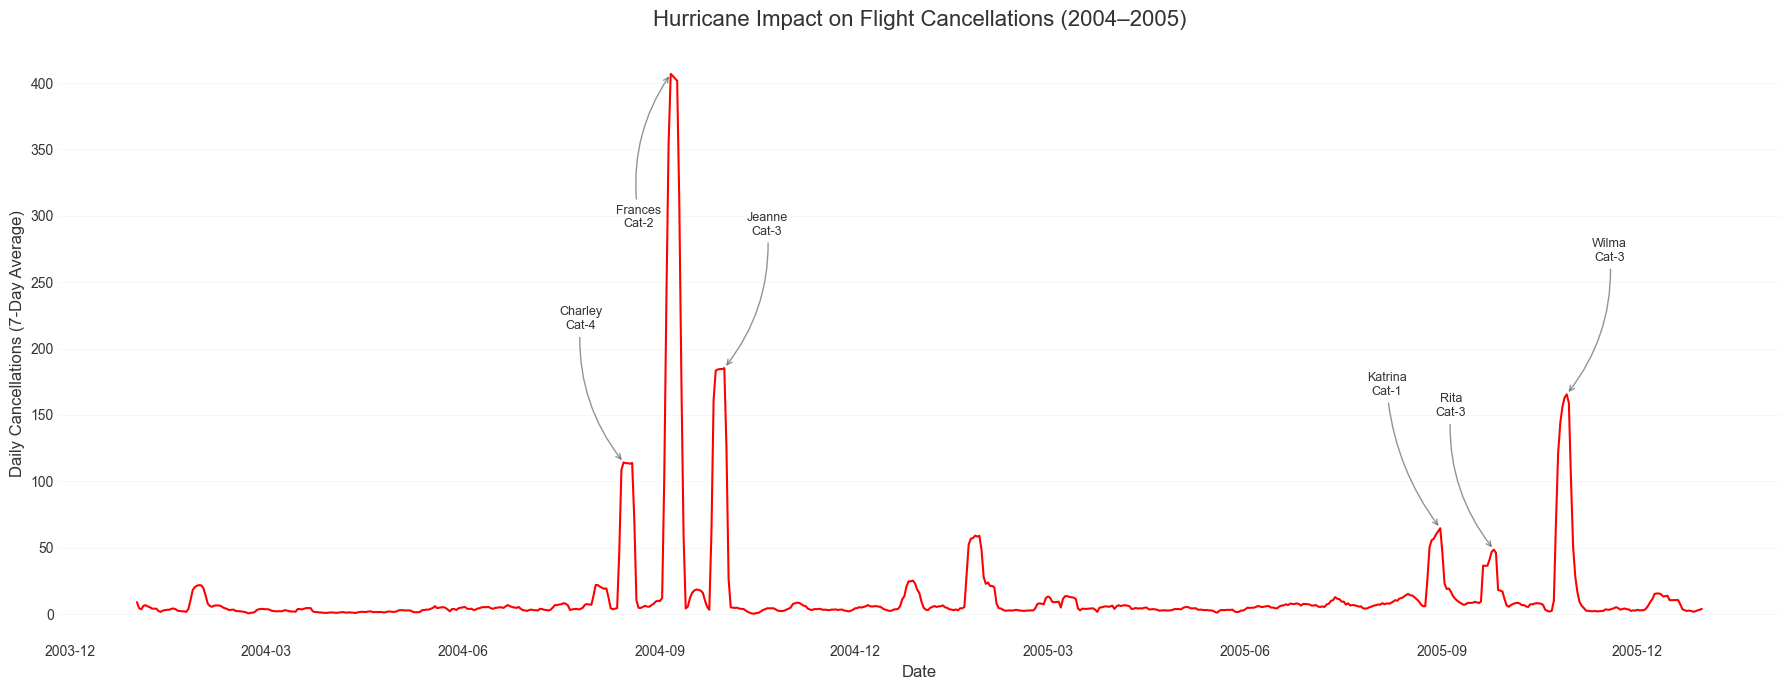

✓ Saved: ../visualizations/plot1.png


<Figure size 1400x600 with 0 Axes>

In [5]:
import matplotlib.dates as mdates

# Create figure with white background
fig, ax = plt.subplots(figsize=(18, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Main line - simple thin gray line for 7-day average
ax.plot(
    daily_stats["FlightDate"],
    daily_stats["Cancellations_7DayAvg"],
    color='red',
    linewidth=1.5,
    zorder=2
)

# Define major hurricanes with custom positioning
# Format: (x_offset_days, position, curve_direction)
hurricane_positions = {
    'Charley': (-20, 'above', 0.2),     # πάνω-αριστερά
    'Frances': (-15, 'below', -0.2),    # κάτω-αριστερά  
    'Jeanne': (20, 'above', -0.2),      # πάνω-δεξιά
    'Katrina': (-25, 'above', 0.15),    # πάνω-αριστερά
    'Rita': (-20, 'above', 0.2),        # πάνω-αριστερά
    'Wilma': (20, 'above', -0.2)        # πάνω-δεξιά
}

# Add labels with arrows for major hurricanes
for _, hurricane in hurricanes.iterrows():
    h_date = hurricane["Date"]
    h_name = hurricane["HurricaneName"]
    h_cat = hurricane["Category"]
    
    # Labels ONLY for major hurricanes
    if h_name in hurricane_positions:
        # Find the peak cancellation near this hurricane date
        window_start = h_date - pd.Timedelta(days=3)
        window_end = h_date + pd.Timedelta(days=7)
        window_data = daily_stats[
            (daily_stats["FlightDate"] >= window_start) & 
            (daily_stats["FlightDate"] <= window_end)
        ]
        
        if len(window_data) > 0:
            peak_idx = window_data["Cancellations_7DayAvg"].idxmax()
            peak_date = daily_stats.loc[peak_idx, "FlightDate"]
            peak_value = daily_stats.loc[peak_idx, "Cancellations_7DayAvg"]
            
            # Get custom positioning for this hurricane
            x_offset_days, position, curve_rad = hurricane_positions[h_name]
            
            # Calculate label position
            y_range = ax.get_ylim()[1] - ax.get_ylim()[0]
            
            if position == 'above':
                label_y = peak_value + y_range * 0.22
                va = 'bottom'
            else:
                label_y = peak_value - y_range * 0.22
                va = 'top'
            
            label_x = peak_date + pd.Timedelta(days=x_offset_days)
            
            # Add annotation with custom curved arrow
            ax.annotate(
                f"{h_name}\nCat-{h_cat}",
                xy=(peak_date, peak_value),
                xytext=(label_x, label_y),
                ha='center',
                va=va,
                fontsize=9,
                color='#333333',
                arrowprops=dict(
                    arrowstyle='->', 
                    connectionstyle=f'arc3,rad={curve_rad}',
                    color='#666666',
                    lw=1.0,
                    alpha=0.7
                ),
                zorder=3
            )

# Clean styling
ax.set_title(
    "Hurricane Impact on Flight Cancellations (2004–2005)",
    fontsize=16,
    fontweight='normal',
    pad=15,
    color='#333333'
)
ax.set_xlabel("Date", fontsize=12, color='#333333')
ax.set_ylabel("Daily Cancellations (7-Day Average)", fontsize=12, color='#333333')

# X-axis formatting
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.tick_params(axis='x', labelsize=10, colors='#333333')
ax.tick_params(axis='y', labelsize=10, colors='#333333')

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

# Subtle horizontal gridlines only
ax.grid(True, axis='y', alpha=0.3, linestyle='-', linewidth=0.5, color='#DDDDDD')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

# Finalize and save plot
finalize_plot(fig, 'plot1.png')

### Plot 1: Hurricane Timeline Analysis (2004-2005)

**Overview:** Four major hurricanes struck Florida within a six-week period in 2004, creating unprecedented disruption to air travel operations.

**Key Findings:**
- **Hurricane Frances (Cat-2, Sep 5)** caused the worst single-day impact with **957 flight cancellations**
- **2004 season total**: 5,040 cancellations vs 2005: 4,600 cancellations
- **Critical insight**: Hurricane category does not directly correlate with operational impact
- Frances (Category 2) caused more disruption than Charley (Category 4) due to size and slow movement
- Temporal clustering of events creates cascading effects on airline operations

### Visualization 2: Hurricane Impact Timeline View

**What This Shows:**
- Connected scatter plot showing peak cancellations for each hurricane
- Color-coded by year (2004 vs 2005)
- Hurricane category annotations

**Key Pattern:** Direct comparison of impact magnitude across all 7 hurricanes


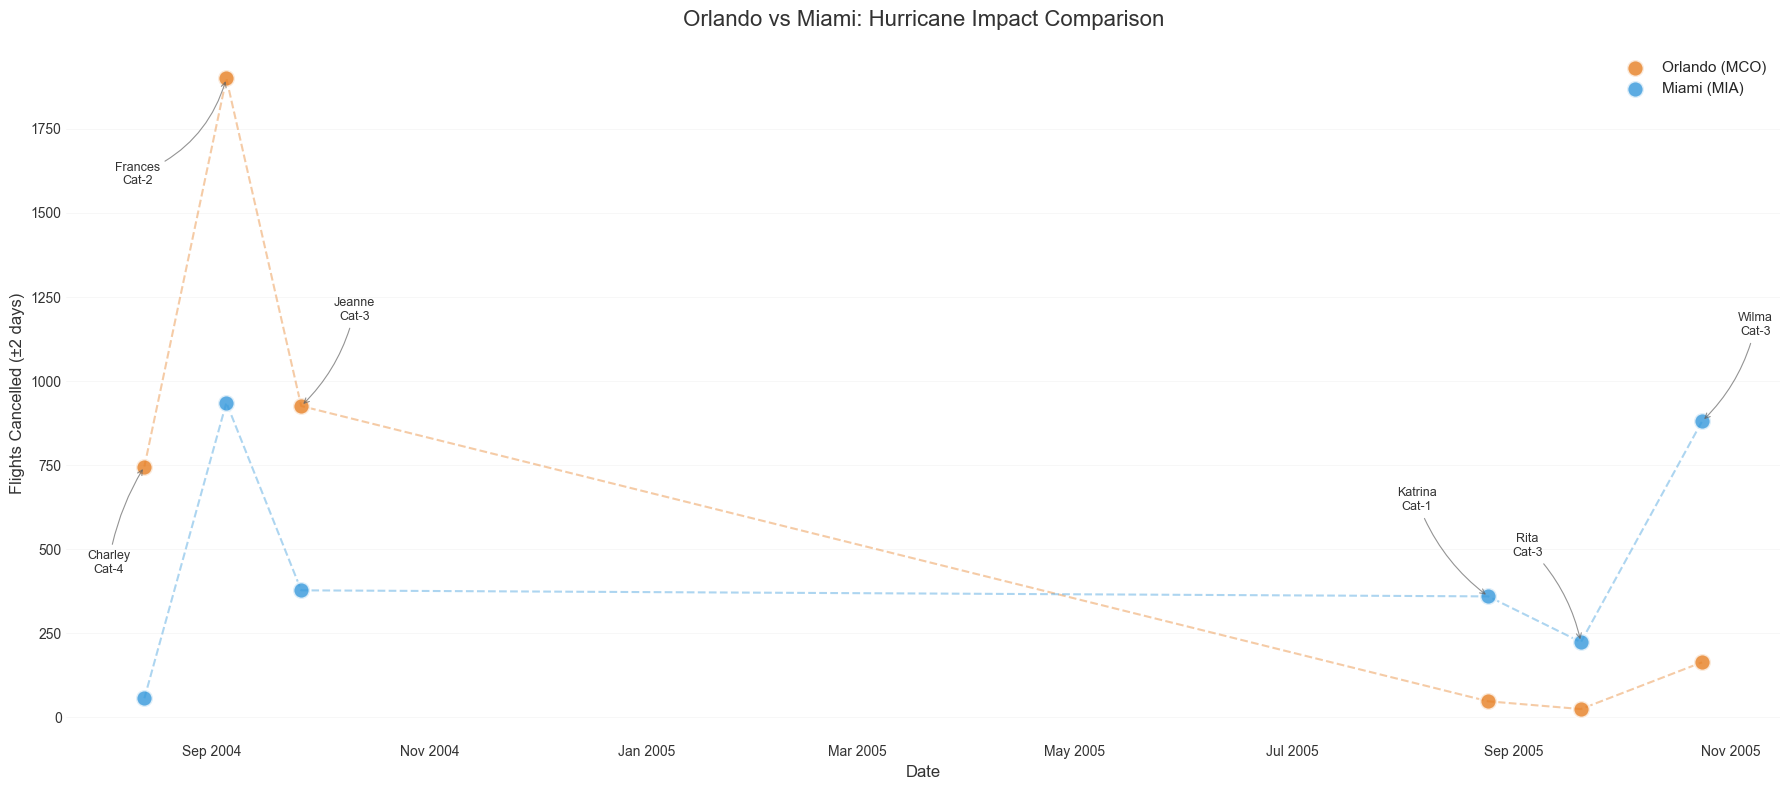

✓ Saved: ../visualizations/plot2.png


<Figure size 1400x600 with 0 Axes>

In [6]:
# MCO vs MIA Hurricane Impact Timeline
fig, ax = plt.subplots(figsize=(18, 8))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Calculate impact for each major hurricane
mco_impacts = []
mia_impacts = []
dates = []
names = []
categories = []

for _, hurricane in hurricanes.iterrows():
    if hurricane["HurricaneName"] in ['Charley', 'Frances', 'Jeanne', 'Katrina', 'Rita', 'Wilma']:
        h_date = hurricane["Date"]
        
        # Get ±2 days window
        window_start = h_date - pd.Timedelta(days=2)
        window_end = h_date + pd.Timedelta(days=2)
        
        # MCO cancellations
        mco_window = daily_mco[
            (daily_mco["FlightDate"] >= window_start) & 
            (daily_mco["FlightDate"] <= window_end)
        ]
        mco_cancelled = mco_window["Cancelled"].sum() if len(mco_window) > 0 else 0
        
        # MIA cancellations
        mia_window = daily_mia[
            (daily_mia["FlightDate"] >= window_start) & 
            (daily_mia["FlightDate"] <= window_end)
        ]
        mia_cancelled = mia_window["Cancelled"].sum() if len(mia_window) > 0 else 0
        
        mco_impacts.append(mco_cancelled)
        mia_impacts.append(mia_cancelled)
        dates.append(h_date)
        names.append(hurricane["HurricaneName"])
        categories.append(hurricane["Category"])

# Plot connecting lines
ax.plot(dates, mco_impacts, color='#E67E22', linewidth=1.5, linestyle='--', alpha=0.4, zorder=1)
ax.plot(dates, mia_impacts, color='#3498DB', linewidth=1.5, linestyle='--', alpha=0.4, zorder=1)

# Plot points
ax.scatter(dates, mco_impacts, s=150, color='#E67E22', alpha=0.8, 
           edgecolors='white', linewidth=2, marker='o', label='Orlando (MCO)', zorder=3)
ax.scatter(dates, mia_impacts, s=150, color='#3498DB', alpha=0.8,
           edgecolors='white', linewidth=2, marker='o', label='Miami (MIA)', zorder=3)

# Custom label positioning to avoid overlaps
label_positions = {
    'Charley': (-10, 'below', -0.1),     # πιο αριστερά
    'Frances': (-25, 'below', 0.25),     # πιο αριστερά και πάνω
    'Jeanne': (15, 'above', -0.15),
    'Katrina': (-20, 'above', 0.15),
    'Rita': (-15, 'above', -0.15),
    'Wilma': (15, 'above', -0.15)
}

# Add hurricane labels with custom positioning
for name, cat, date, mco_val, mia_val in zip(names, categories, dates, mco_impacts, mia_impacts):
    x_offset_days, position, curve_rad = label_positions[name]
    
    # Use the higher value as reference point
    y_pos = max(mco_val, mia_val)
    
    # Calculate label position
    y_range = ax.get_ylim()[1] - ax.get_ylim()[0]
    
    if position == 'above':
        label_y = y_pos + y_range * 0.12
        va = 'bottom'
    else:
        label_y = y_pos - y_range * 0.12
        va = 'top'
    
    label_x = date + pd.Timedelta(days=x_offset_days)
    
    ax.annotate(
        f"{name}\nCat-{cat}",
        xy=(date, y_pos),
        xytext=(label_x, label_y),
        ha='center',
        va=va,
        fontsize=9,
        color='#333333',
        arrowprops=dict(
            arrowstyle='->',
            connectionstyle=f'arc3,rad={curve_rad}',
            color='#666666',
            lw=0.8,
            alpha=0.7
        ),
        zorder=4
    )

# Clean styling
ax.set_xlabel('Date', fontsize=12, color='#333333')
ax.set_ylabel('Flights Cancelled (±2 days)', fontsize=12, color='#333333')
ax.set_title('Orlando vs Miami: Hurricane Impact Comparison', 
             fontsize=16, fontweight='normal', pad=15, color='#333333')

# X-axis formatting
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.tick_params(axis='x', labelsize=10, colors='#333333', rotation=0)
ax.tick_params(axis='y', labelsize=10, colors='#333333')

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

# Subtle gridlines
ax.grid(True, axis='y', alpha=0.3, linestyle='-', linewidth=0.5, color='#DDDDDD')
ax.set_axisbelow(True)

# Legend
ax.legend(loc='upper right', fontsize=11, framealpha=0.9)

plt.tight_layout()
plt.show()

# Save
finalize_plot(fig, 'plot2.png')

### Plot 2: Geographic Vulnerability - MCO vs MIA

**Overview:** Comparative analysis reveals distinct vulnerability patterns between Orlando and Miami airports during hurricane seasons.

**Key Findings:**
- **MCO devastated in 2004**: Frances caused approximately 1,900 cancellations at Orlando
- **MIA hit harder in 2005**: Katrina, Rita, and Wilma had disproportionate impact on Miami
- **Hurricane trajectory matters more than intensity** for airport-specific impacts
- Geographic positioning creates differential exposure to storm paths
- Airport-specific contingency planning must account for regional hurricane patterns

### Visualization 3: 2004 Hurricane Calendar Heatmap

**What This Shows:**
- GitHub-style contribution graph showing daily cancellations throughout 2004
- Color intensity represents cancellation severity
- Hurricane markers show timing of major events

**Data Period:** January - December 2004


✓ Saved: ../visualizations/plot3.png


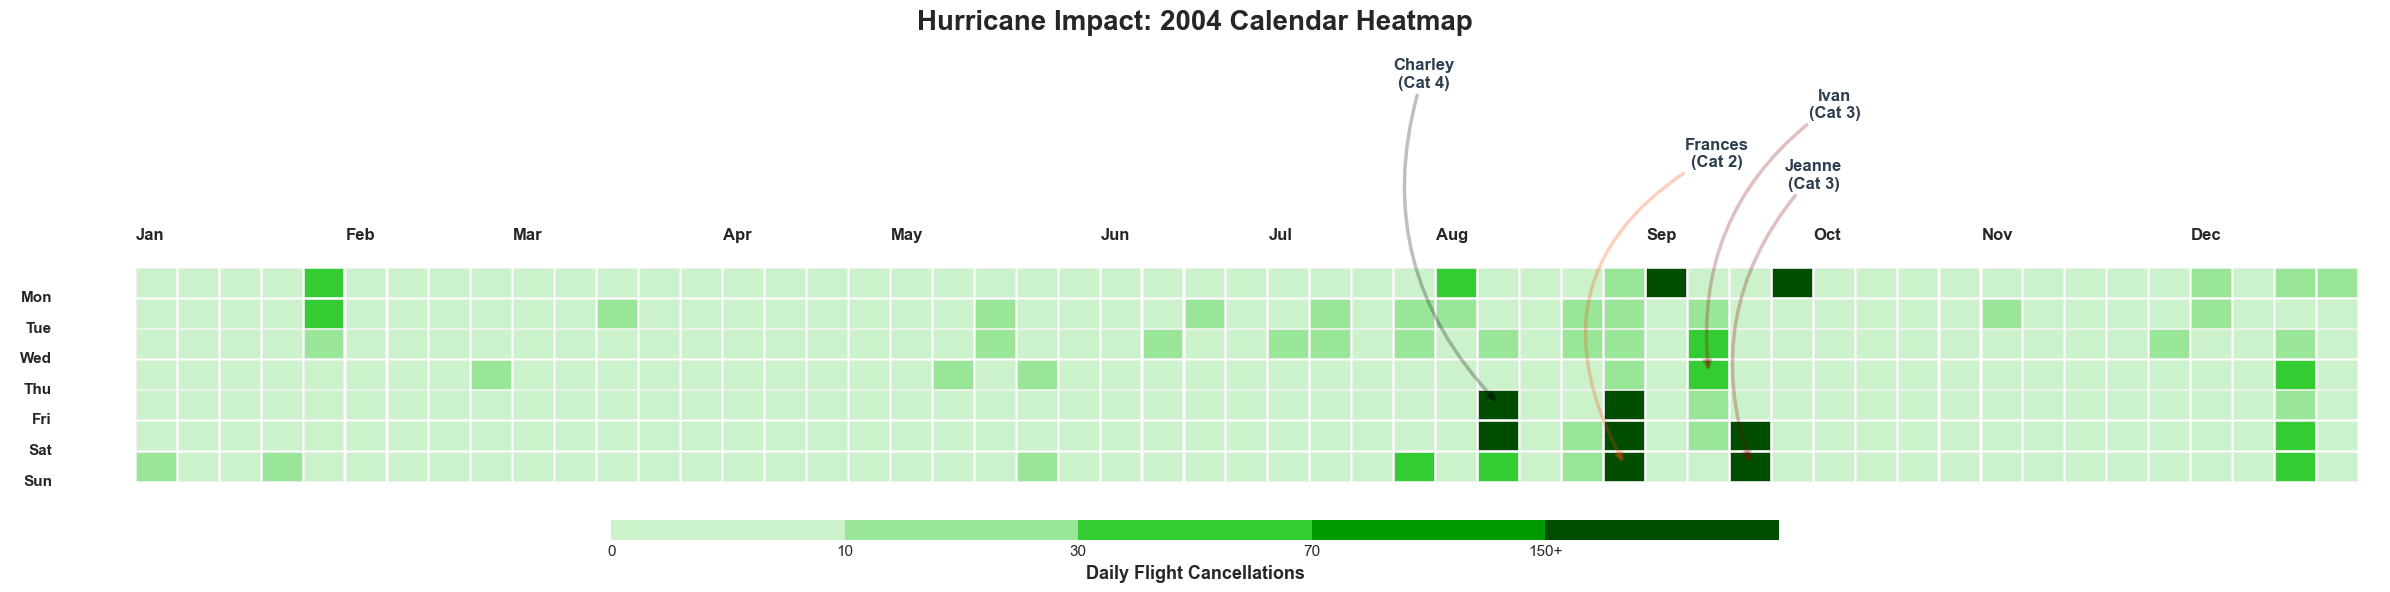

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap, BoundaryNorm
import numpy as np

# Single subplot for 2004 only
fig, ax = plt.subplots(figsize=(24, 6))

colors = ['#ccf2cc', '#99e699', '#33cc33', '#009900', '#004d00']

# 5 bins for cancellation ranges
boundaries = [0, 10, 30, 70, 150, 1000]
norm = BoundaryNorm(boundaries, len(colors))

# Create discrete colormap
cmap = LinearSegmentedColormap.from_list('github', colors, N=len(colors))

# Get all days in 2004
year = 2004
start_date = f'{year}-01-01'
end_date = f'{year}-12-31'
year_data = daily_stats[
    (daily_stats['FlightDate'] >= start_date) &
    (daily_stats['FlightDate'] <= end_date)
].copy()

year_data['Week'] = year_data['FlightDate'].dt.isocalendar().week
year_data['DayOfWeek'] = year_data['FlightDate'].dt.dayofweek
year_data['Month'] = year_data['FlightDate'].dt.month

# Create pivot table - each cell is average cancellations for that day/week
pivot_data = year_data.pivot_table(
    values='Cancelled',
    index='DayOfWeek',
    columns='Week',
    aggfunc='mean',
    fill_value=0
)

# Plot each cell as a colored rectangle
for row_idx, day in enumerate(range(7)):
    for col_idx, week in enumerate(pivot_data.columns):
        if day in pivot_data.index:
            value = pivot_data.loc[day, week]
            
            # Map value to color bin
            norm_value = norm(value)
            color = cmap(norm_value / (len(colors) - 1))
            
            # Draw rectangle
            rect = mpatches.Rectangle(
                (col_idx, 6 - row_idx),
                0.95, 0.95,
                facecolor=color,
                edgecolor='#f0f0f0',
                linewidth=0.5
            )
            ax.add_patch(rect)

# Month labels at top
month_positions = {}
for week in pivot_data.columns:
    week_dates = year_data[year_data['Week'] == week]
    if len(week_dates) > 0:
        month = week_dates['FlightDate'].iloc[0].month
        if month not in month_positions:
            month_positions[month] = list(pivot_data.columns).index(week)

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

for month, pos in month_positions.items():
    ax.text(pos, 7.8, month_names[month-1], 
           fontsize=12, ha='left', va='bottom', fontweight='bold')

# Day labels on left
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
for i, day_name in enumerate(day_names):
    ax.text(-2, 6-i, day_name, fontsize=11, ha='right', va='center', fontweight='semibold')

# Hurricane markers with arrows pointing to exact dates
hurricanes_2004 = hurricanes[hurricanes['Date'].dt.year == 2004]
category_colors_h = {
    4: '#000000',
    3: '#8B0000',
    2: '#FF4500',
    1: '#FFA500'
}

# Custom positioning to avoid label overlap
label_y_positions = {
    'Charley': 12.8,
    'Frances': 10.2,
    'Ivan': 11.8,
    'Jeanne': 9.5
}

label_x_offset = {
    'Charley': -1.8,
    'Frances': 2.2,
    'Ivan': 3.0,
    'Jeanne': 1.5
}

curve_radius = {
    'Charley': 0.3,
    'Frances': 0.5,
    'Ivan': 0.3,
    'Jeanne': 0.3
}

for _, h in hurricanes_2004.iterrows():
    h_date = h['Date']
    h_week = h_date.isocalendar()[1]
    h_dow = h_date.dayofweek
    h_name = h['HurricaneName']
    h_cat = h['Category']
    
    if h_week in pivot_data.columns:
        week_idx = list(pivot_data.columns).index(h_week)
        
        # Exact position of hurricane day
        exact_col = week_idx + 0.5
        exact_row = 6 - h_dow + 0.5
        
        # Label position
        label_y = label_y_positions.get(h_name, 11)
        x_offset = label_x_offset.get(h_name, 0)
        label_x = exact_col + x_offset
        
        label_text = f"{h_name}\n(Cat {h_cat})"
        
        ax.annotate(
            label_text,
            xy=(exact_col, exact_row),
            xytext=(label_x, label_y),
            fontsize=12,
            fontweight='bold',
            color='#2c3e50',
            ha='center',
            va='bottom',
            arrowprops=dict(
                arrowstyle='-|>',
                color=category_colors_h.get(h_cat, '#8B0000'),
                lw=2.5,
                alpha=0.25,
                connectionstyle=f'arc3,rad={curve_radius.get(h_name, 0.3)}'
            ),
            zorder=10
        )

# Set plot limits and remove axes
ax.set_xlim(-3, len(pivot_data.columns) + 0.5)
ax.set_ylim(-0.5, 14)
ax.axis('off')

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', 
                    pad=0.05, aspect=60, shrink=0.7, fraction=0.04,
                    spacing='uniform')
cbar.set_label('Daily Flight Cancellations', fontsize=13, fontweight='bold')
cbar.set_ticks([0, 10, 30, 70, 150])
cbar.set_ticklabels(['0', '10', '30', '70', '150+'])
cbar.ax.tick_params(labelsize=11)

plt.suptitle('Hurricane Impact: 2004 Calendar Heatmap', 
            fontsize=20, fontweight='bold', y=0.98)

# Finalize and save plot
finalize_plot(fig, 'plot3.png')


### Plot 3: Seasonal Traffic Patterns - MCO vs MIA

**Overview:** Two Florida airports demonstrate fundamentally opposite seasonal patterns, reflecting distinct tourism markets.

**Key Findings:**
- **MCO peaks in summer** (Jun-Aug): Driven by theme park tourism and family travel
- **MIA peaks in winter** (Dec-Mar): Snowbird migration and Caribbean cruise departures
- **Opposite seasonality** indicates different market segments and airport functions
- September represents lowest traffic for both airports (hurricane season avoidance)
- Airport function (leisure destination vs international hub) determines traffic patterns

## Section 7: Data Preparation - Monthly Aggregations

Creating monthly statistics for MCO and MIA to analyze seasonal tourism patterns.

In [8]:
# Helper function for creating monthly aggregations
def create_monthly_aggregation(data, airport_name):
    """
    Create monthly aggregation for an airport.
    
    Parameters:
    - data: DataFrame filtered for specific airport
    - airport_name: Name of the airport (for labeling)
    
    Returns:
    - DataFrame with monthly aggregated flight statistics
    """
    # Extract year and month from FlightDate
    monthly_stats = data.groupby([
        data['FlightDate'].dt.year.rename('Year'),
        data['FlightDate'].dt.month.rename('Month')
    ]).agg({
        'FlightNum': 'count',
        'Cancelled': 'sum',
        'ArrDelay': 'mean',
        'DepDelay': 'mean'
    }).reset_index()
    
    # Add airport identifier
    monthly_stats['Airport'] = airport_name
    
    return monthly_stats

In [9]:
# Use full dataset (2004-2008) for robust seasonal patterns
story2_data = df.copy()

print(f"Story 2 analysis period: {story2_data['FlightDate'].min()} to {story2_data['FlightDate'].max()}")
print(f"Total flights: {len(story2_data):,}")
print()

# Create monthly aggregations using helper function
monthly_mco = create_monthly_aggregation(story2_data[story2_data['IsMCO']], 'MCO')
monthly_mia = create_monthly_aggregation(story2_data[story2_data['IsMIA']], 'MIA')

# Combine for easier plotting
monthly_combined = pd.concat([monthly_mco, monthly_mia])
monthly_combined['YearMonth'] = pd.to_datetime(
    monthly_combined['Year'].astype(str) + '-' + monthly_combined['Month'].astype(str).str.zfill(2) + '-01'
)

print(f"\nMonthly combined data shape: {monthly_combined.shape}")


Story 2 analysis period: 2004-01-01 00:00:00 to 2008-04-30 00:00:00
Total flights: 1,592,198


Monthly combined data shape: (104, 8)


### Key Findings from Metrics:

The quantitative analysis reveals stark differences in tourism patterns:

1. **Opposite Peak Seasons**
   - MCO peaks in summer months (families + school vacation)
   - MIA peaks in winter months (snowbirds + cruise season)
   - This divergence creates natural tourism diversification for Florida

2. **Seasonality Intensity**
   - Both airports show significant seasonal variation (35-45% range)
   - MIA may be more seasonal despite year-round cruise operations
   - Winter snowbird effect dominates Miami's annual rhythm

3. **Peak Concentration**
   - Top 3 months represent 28-32% of annual flights
   - Shows importance of capacity planning for seasonal surges
   - Different peak timing means Florida airports complement rather than compete

---

## Section 9: Visualization 2 - Calendar Heatmap Comparison

### Question: Can we see the seasonal patterns in a daily calendar view?

✓ Saved: ../visualizations/plot4.png


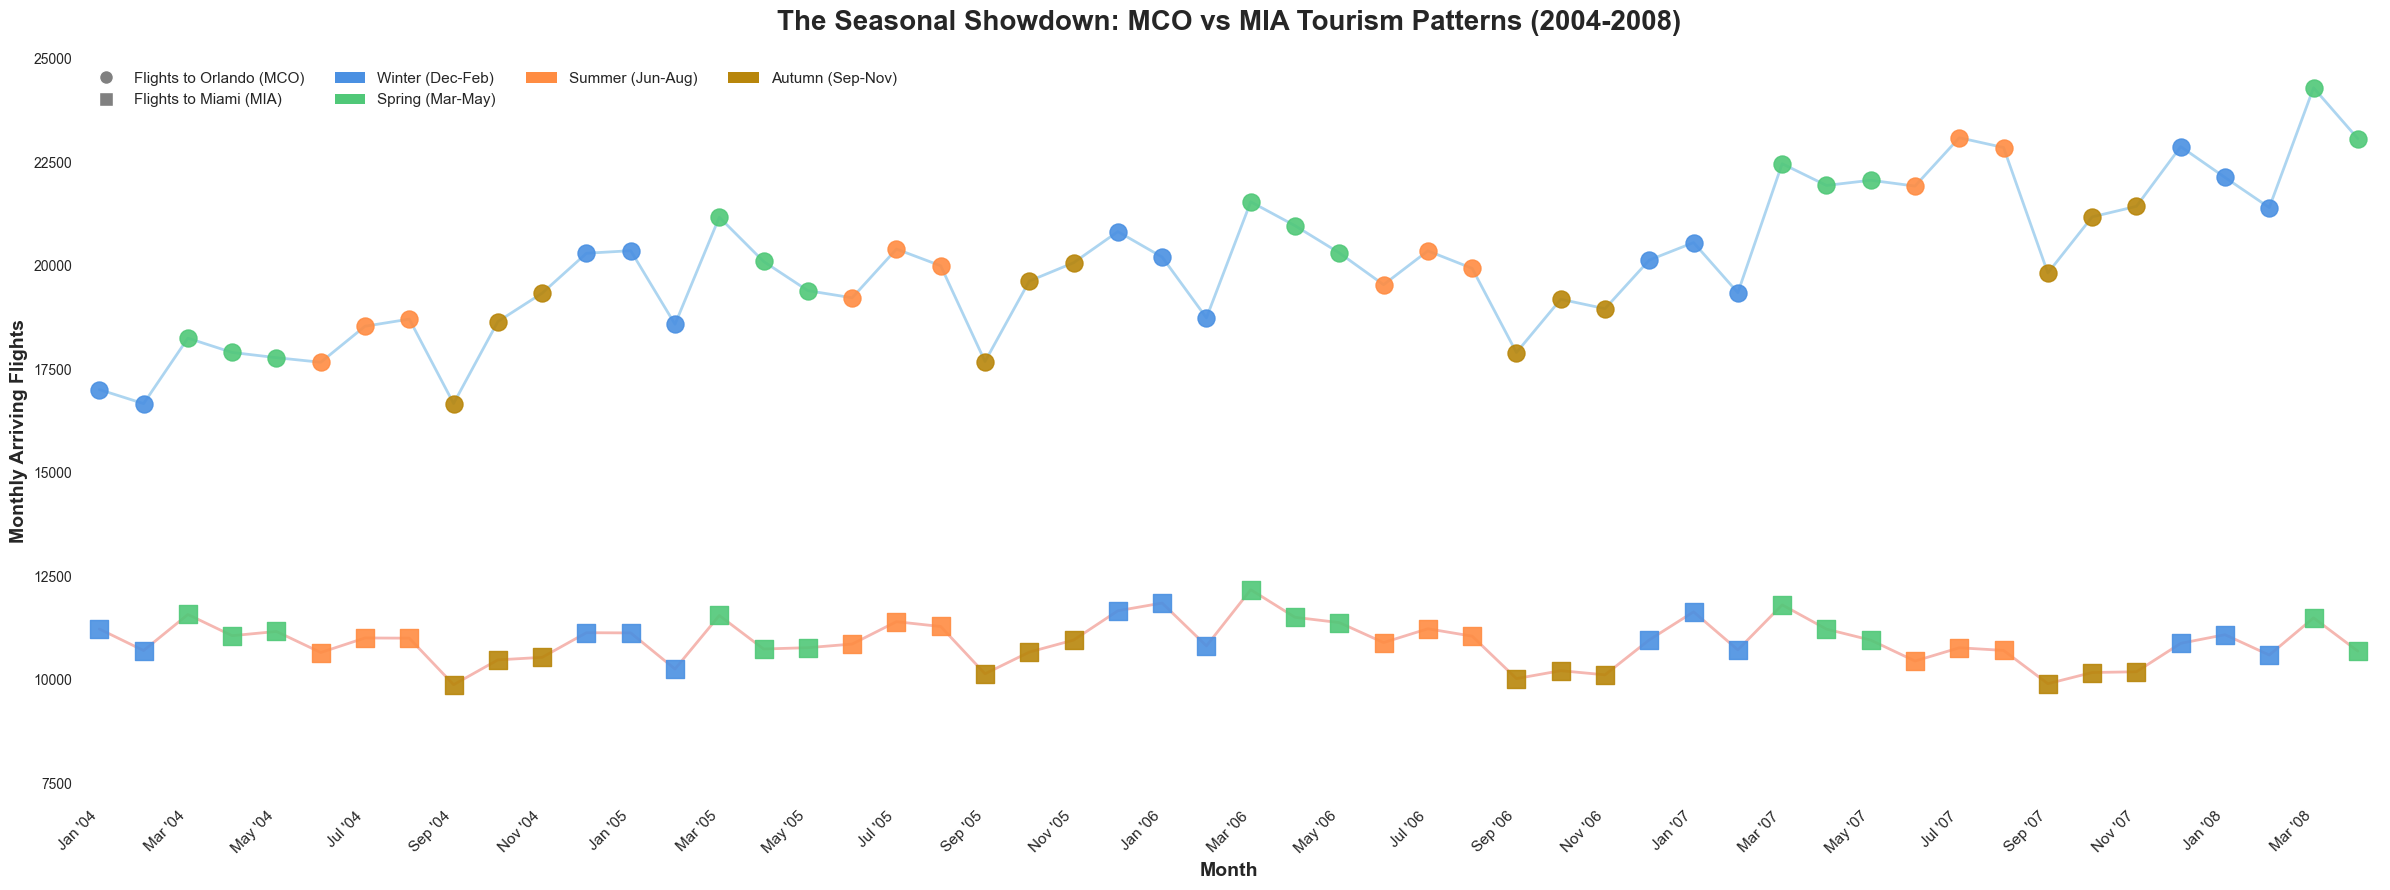

In [10]:
# VIZ 1: The Seasonal Showdown - MCO vs MIA Monthly Patterns (2004-2008)

# Filter for ALL 5 years (2004-2008)
years_to_plot = [2004, 2005, 2006, 2007, 2008]

# Handle both MultiIndex and regular DataFrame structures
if isinstance(monthly_mco.index, pd.MultiIndex):
    mco_filtered = monthly_mco[monthly_mco.index.get_level_values('Year').isin(years_to_plot)].copy()
    mia_filtered = monthly_mia[monthly_mia.index.get_level_values('Year').isin(years_to_plot)].copy()
    mco_filtered = mco_filtered.reset_index()
    mia_filtered = mia_filtered.reset_index()
else:
    mco_filtered = monthly_mco[monthly_mco['Year'].isin(years_to_plot)].copy()
    mia_filtered = monthly_mia[monthly_mia['Year'].isin(years_to_plot)].copy()

# Create month labels
month_abbr = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
              7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}

mco_filtered['MonthLabel'] = mco_filtered.apply(
    lambda row: f"{month_abbr[row['Month']]} '{str(row['Year'])[2:]}", axis=1
)
mia_filtered['MonthLabel'] = mia_filtered.apply(
    lambda row: f"{month_abbr[row['Month']]} '{str(row['Year'])[2:]}", axis=1
)

# Sort by year and month
mco_filtered = mco_filtered.sort_values(['Year', 'Month']).reset_index(drop=True)
mia_filtered = mia_filtered.sort_values(['Year', 'Month']).reset_index(drop=True)

# Define season colors - more distinct and vibrant
season_colors = {
    'Winter': '#4A90E2',      # Bright blue
    'Spring': '#50C878',      # Emerald green
    'Summer': '#FF8C42',      # Coral orange
    'Autumn': '#B8860B'       # Dark goldenrod
}

# Assign season colors based on month
def get_season_color(month):
    if month in [12, 1, 2]:
        return season_colors['Winter']
    elif month in [3, 4, 5]:
        return season_colors['Spring']
    elif month in [6, 7, 8]:
        return season_colors['Summer']
    elif month in [9, 10, 11]:
        return season_colors['Autumn']

mco_filtered['SeasonColor'] = mco_filtered['Month'].apply(get_season_color)
mia_filtered['SeasonColor'] = mia_filtered['Month'].apply(get_season_color)

# Create the plot
fig, ax = plt.subplots(figsize=(24, 9))

# White background
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

# Plot lines connecting points
ax.plot(mco_filtered.index, mco_filtered['FlightNum'],
        color=COLORS['MCO'], linewidth=2, alpha=0.4, zorder=2)
ax.plot(mia_filtered.index, mia_filtered['FlightNum'],
        color=COLORS['MIA'], linewidth=2, alpha=0.4, zorder=2)

# Plot markers with season colors - NO EDGE for maximum color visibility
for idx, row in mco_filtered.iterrows():
    ax.scatter(idx, row['FlightNum'], 
               color=row['SeasonColor'], 
               s=150, marker='o',
               zorder=3, alpha=0.9)

for idx, row in mia_filtered.iterrows():
    ax.scatter(idx, row['FlightNum'], 
               color=row['SeasonColor'], 
               s=150, marker='s',
               zorder=3, alpha=0.9)

# X-axis configuration
ax.set_xlabel('Month', fontsize=14, fontweight='semibold')
ax.set_ylabel('Monthly Arriving Flights', fontsize=14, fontweight='semibold')

# Custom x-axis labels - show every 3rd month
tick_positions = []
tick_labels = []
for idx, row in mco_filtered.iterrows():
    if row['Month'] in [1, 3, 5, 7, 9, 11]:
        tick_positions.append(idx)
        tick_labels.append(row['MonthLabel'])

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=11)

# Title
ax.set_title('The Seasonal Showdown: MCO vs MIA Tourism Patterns (2004-2008)',
             fontsize=20, fontweight='bold', pad=20)

# Create unified legend
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
           markersize=10, label='Flights to Orlando (MCO)', linestyle='None'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='gray',
           markersize=10, label='Flights to Miami (MIA)', linestyle='None'),
    Patch(facecolor=season_colors['Winter'], label='Winter (Dec-Feb)'),
    Patch(facecolor=season_colors['Spring'], label='Spring (Mar-May)'),
    Patch(facecolor=season_colors['Summer'], label='Summer (Jun-Aug)'),
    Patch(facecolor=season_colors['Autumn'], label='Autumn (Sep-Nov)'),
]

ax.legend(handles=legend_elements, loc='upper left', ncol=4, fontsize=11, 
          framealpha=0.95, edgecolor='gray', fancybox=True)

# Grid and styling
ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.8, axis='y', zorder=0)
ax.set_ylim(bottom=7000)
ax.set_xlim(left=-0.5, right=len(mco_filtered) - 0.5)

# Remove top and right spines for cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Finalize and save plot
finalize_plot(fig, 'plot4.png')

### Plot 4: Monthly Flight Volume Analysis

**Overview:** Granular monthly analysis quantifies seasonal variation in flight operations.

**Key Findings:**
- **MCO summer surge**: Approximately 40% increase in flights during June-August
- **MIA winter peak**: Highest traffic January-March, coinciding with winter tourism season
- **September minimum** at both airports correlates with hurricane season peak
- Behavioral response to hurricane risk evident in passenger and airline avoidance patterns
- Pronounced seasonality creates operational challenges for workforce and capacity management

In [11]:
# Airport code to city name mapping
airport_cities = {
    'ATL': 'Atlanta', 'PHL': 'Philadelphia', 'JFK': 'New York', 
    'BWI': 'Baltimore', 'EWR': 'Newark', 'DFW': 'Dallas',
    'ORD': 'Chicago', 'IAD': 'Washington DC', 'BOS': 'Boston',
    'MDW': 'Chicago', 'CLT': 'Charlotte', 'DTW': 'Detroit',
    'LGA': 'New York', 'PIT': 'Pittsburgh', 'SJU': 'San Juan',
    'DCA': 'Washington DC', 'IAH': 'Houston', 'LAX': 'Los Angeles',
    'TPA': 'Tampa', 'FLL': 'Fort Lauderdale', 'MSP': 'Minneapolis',
    'DEN': 'Denver', 'PHX': 'Phoenix', 'SFO': 'San Francisco',
    'SEA': 'Seattle', 'CVG': 'Cincinnati', 'STL': 'St. Louis',
    'CLE': 'Cleveland', 'MEM': 'Memphis', 'RDU': 'Raleigh',
    'BNA': 'Nashville', 'AUS': 'Austin', 'SAN': 'San Diego',
    'PDX': 'Portland', 'HOU': 'Houston', 'DAL': 'Dallas'
}


In [12]:
# PLOT 1: Top Destinations by Season - Data Preparation (UPDATED)
# EXCLUDE inter-airport flights AND exclude MCO/MIA as destinations entirely
# Get top destinations by season for MCO (excluding both MIA and MCO as destinations)
mco_season_dest = (df[df['IsMCO'] & (~df['Dest'].isin(['MIA', 'MCO']))]
                   .groupby(['Season', 'Dest'])
                   .agg({'FlightNum': 'count'})
                   .reset_index())

mco_season_dest.rename(columns={'FlightNum': 'FlightCount'}, inplace=True)
mco_season_dest['Airport'] = 'MCO'

# Get top destinations by season for MIA (excluding both MCO and MIA as destinations)
mia_season_dest = (df[df['IsMIA'] & (~df['Dest'].isin(['MCO', 'MIA']))]
                   .groupby(['Season', 'Dest'])
                   .agg({'FlightNum': 'count'})
                   .reset_index())

mia_season_dest.rename(columns={'FlightNum': 'FlightCount'}, inplace=True)
mia_season_dest['Airport'] = 'MIA'

# For each season, get top 8 destinations (union of MCO and MIA top destinations)
seasons_order = ['Winter', 'Spring', 'Summer', 'Fall']
top_dests_by_season = {}

for season in seasons_order:
    # Get top 8 MCO destinations for this season
    mco_top = mco_season_dest[mco_season_dest['Season'] == season].nlargest(8, 'FlightCount')['Dest'].tolist()
    
    # Get top 8 MIA destinations for this season
    mia_top = mia_season_dest[mia_season_dest['Season'] == season].nlargest(8, 'FlightCount')['Dest'].tolist()
    
    # Take union to get all important destinations
    all_top = list(set(mco_top[:8] + mia_top[:8]))
    
    # Get flight counts for these destinations
    season_mco = mco_season_dest[(mco_season_dest['Season'] == season) & 
                                  (mco_season_dest['Dest'].isin(all_top))]
    season_mia = mia_season_dest[(mia_season_dest['Season'] == season) & 
                                  (mia_season_dest['Dest'].isin(all_top))]
    
    # Combine and fill missing destinations with 0
    combined = pd.DataFrame({'Dest': all_top})
    combined = combined.merge(season_mco[['Dest', 'FlightCount']], on='Dest', how='left')
    combined.rename(columns={'FlightCount': 'MCO_Flights'}, inplace=True)
    combined = combined.merge(season_mia[['Dest', 'FlightCount']], on='Dest', how='left')
    combined.rename(columns={'FlightCount': 'MIA_Flights'}, inplace=True)
    combined.fillna(0, inplace=True)
    
    # Sort by total flights (MCO + MIA) and keep top 8
    combined['Total'] = combined['MCO_Flights'] + combined['MIA_Flights']
    combined = combined.nlargest(8, 'Total').sort_values('Total', ascending=True)
    
    top_dests_by_season[season] = combined

print("✓ Top destinations by season prepared (MCO↔MIA flights excluded)")


✓ Top destinations by season prepared (MCO↔MIA flights excluded)


### Visualization 5: Seasonal Destination Preferences

**What This Shows:**
- Top 10 destinations from MCO and MIA for each season
- Side-by-side comparison shows airport-specific patterns
- Flight counts reveal destination popularity

**Data Period:** 2004-2008 (5 years for robust patterns)


✓ Saved: ../visualizations/plot5.png


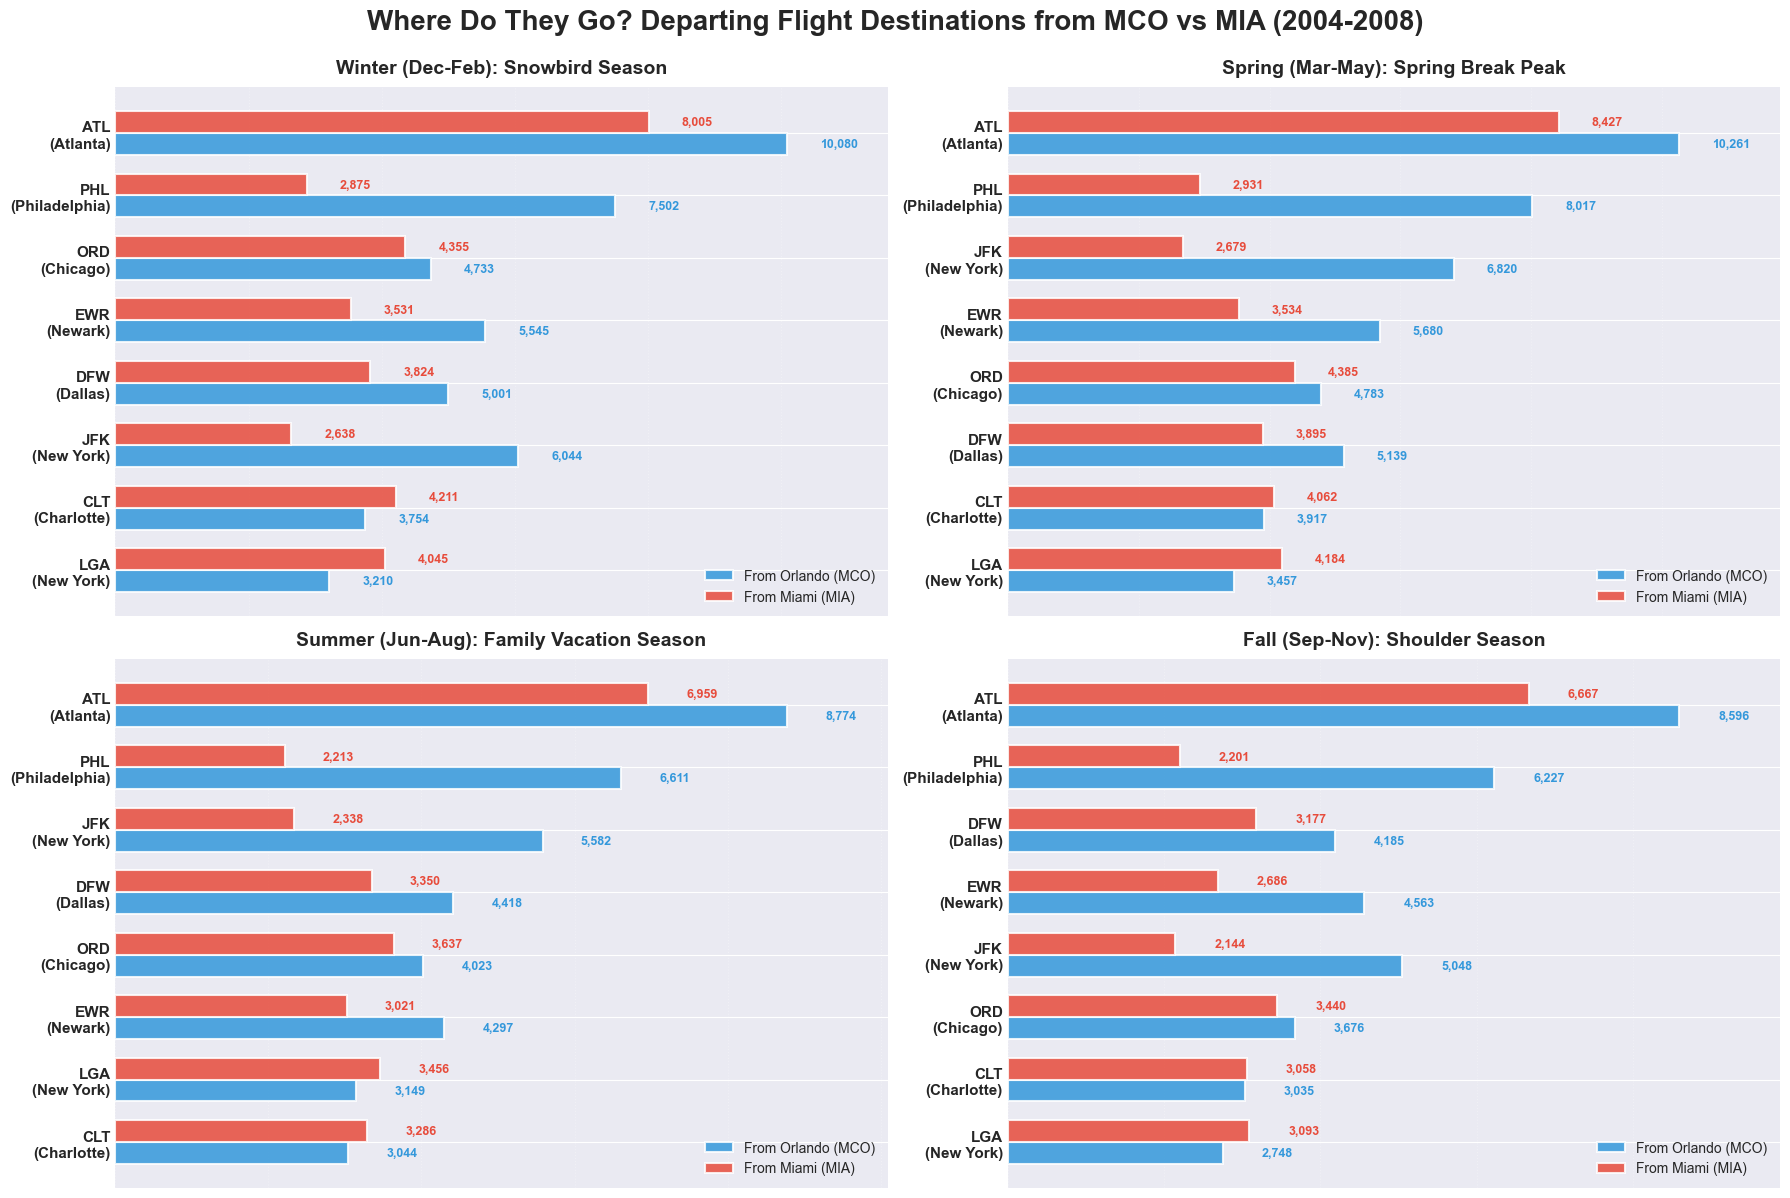

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

seasons_order = ['Winter', 'Spring', 'Summer', 'Fall']
season_descriptions = {
    'Winter': 'Winter (Dec-Feb): Snowbird Season',
    'Spring': 'Spring (Mar-May): Spring Break Peak',
    'Summer': 'Summer (Jun-Aug): Family Vacation Season',
    'Fall': 'Fall (Sep-Nov): Shoulder Season'
}

for idx, season in enumerate(seasons_order):
    ax = axes[idx]
    data = top_dests_by_season[season]
    
    # Y positions for bars
    y_pos = np.arange(len(data))
    bar_height = 0.35
    
    # Plot grouped horizontal bars
    bars1 = ax.barh(y_pos - bar_height/2, data['MCO_Flights'], 
                     bar_height, label='From Orlando (MCO)',
                     color=COLORS['MCO'], alpha=0.85, edgecolor='white', linewidth=1.5)
    
    bars2 = ax.barh(y_pos + bar_height/2, data['MIA_Flights'], 
                     bar_height, label='From Miami (MIA)',
                     color=COLORS['MIA'], alpha=0.85, edgecolor='white', linewidth=1.5)
    
    # Add value labels on bars
    for bar in bars1:
        width = bar.get_width()
        if width > 0:
            ax.text(width + 500, bar.get_y() + bar.get_height()/2,
                   f'{int(width):,}',
                   ha='left', va='center', fontsize=9, fontweight='semibold',
                   color=COLORS['MCO'])
    
    for bar in bars2:
        width = bar.get_width()
        if width > 0:
            ax.text(width + 500, bar.get_y() + bar.get_height()/2,
                   f'{int(width):,}',
                   ha='left', va='center', fontsize=9, fontweight='semibold',
                   color=COLORS['MIA'])
    
    # Styling
    ax.set_yticks(y_pos)
    # Create labels with city names: "ATL (Atlanta)"
    labels = [f"{dest}\n({airport_cities.get(dest, '')})" for dest in data['Dest']]
    ax.set_yticklabels(labels, fontsize=11, fontweight='semibold')
    # ax.set_xlabel('Number of Flights', fontsize=12, fontweight='semibold')
    ax.set_xticklabels([])  # Remove x-axis tick labels
    ax.set_title(season_descriptions[season], 
                fontsize=14, fontweight='bold', pad=10)
    
    # # Apply K formatter to x-axis
    # ax.xaxis.set_major_formatter(FuncFormatter(thousands_formatter))
    
    # Grid and legend
    ax.grid(True, axis='x', alpha=0.3, linestyle=':', linewidth=0.8)
    ax.legend(loc='lower right', fontsize=10, framealpha=0.95, shadow=True)
    
    # Set x-axis limits with padding for labels
    max_flights = max(data['MCO_Flights'].max(), data['MIA_Flights'].max())
    ax.set_xlim(0, max_flights * 1.15)

# Overall title
fig.suptitle('Where Do They Go? Departing Flight Destinations from MCO vs MIA (2004-2008)',
            fontsize=20, fontweight='bold', y=0.995)

# Finalize and save plot
finalize_plot(fig, 'plot5.png')


### Plot 5: Top Destination Routes by Season

**Overview:** Route analysis identifies destination preferences and seasonal shifts in travel patterns.

**Key Findings:**
- **ATL dominates both airports**: Atlanta's position as Delta hub creates asymmetric traffic flows
- **Seasonal route shifts**: Caribbean routes peak winter, domestic routes increase summer
- **MCO**: Predominantly domestic focus, consistent with leisure travel market
- **MIA**: International gateway characteristics with strong Latin America connectivity
- Hub-and-spoke network structure creates concentration in destination distributions

In [14]:
# PLOT 2: Distance vs Delay - Data Preparation (OPTIMIZED)
# Get top 10 destinations for MCO (excluding MCO/MIA as destinations)
mco_top_dests = (df[(df['IsMCO']) & (~df['Dest'].isin(['MCO', 'MIA']))]
                 .groupby('Dest')
                 .agg({'FlightNum': 'count', 'Distance': 'mean', 'ArrDelay': 'mean'})
                 .reset_index()
                 .nlargest(10, 'FlightNum')
                 .assign(Origin='MCO'))

# Get top 10 destinations for MIA (excluding MCO/MIA as destinations)
mia_top_dests = (df[(df['IsMIA']) & (~df['Dest'].isin(['MCO', 'MIA']))]
                 .groupby('Dest')
                 .agg({'FlightNum': 'count', 'Distance': 'mean', 'ArrDelay': 'mean'})
                 .reset_index()
                 .nlargest(10, 'FlightNum')
                 .assign(Origin='MIA'))

print(f"✓ Data prepared: {len(mco_top_dests)} MCO routes, {len(mia_top_dests)} MIA routes")
print(f"MCO avg delay: {mco_top_dests['ArrDelay'].mean():.1f} min")
print(f"MIA avg delay: {mia_top_dests['ArrDelay'].mean():.1f} min")


✓ Data prepared: 10 MCO routes, 10 MIA routes
MCO avg delay: 9.7 min
MIA avg delay: 12.0 min


### Visualization 6: Distance vs Delay Performance

**What This Shows:**
- Top 10 destinations plotted by distance vs average arrival delay
- Performance zones: Green (excellent), Yellow (good), Red (poor)
- Reveals which routes consistently underperform

**Key Question:** Does distance predict delays?


✓ Saved: ../visualizations/plot6.png


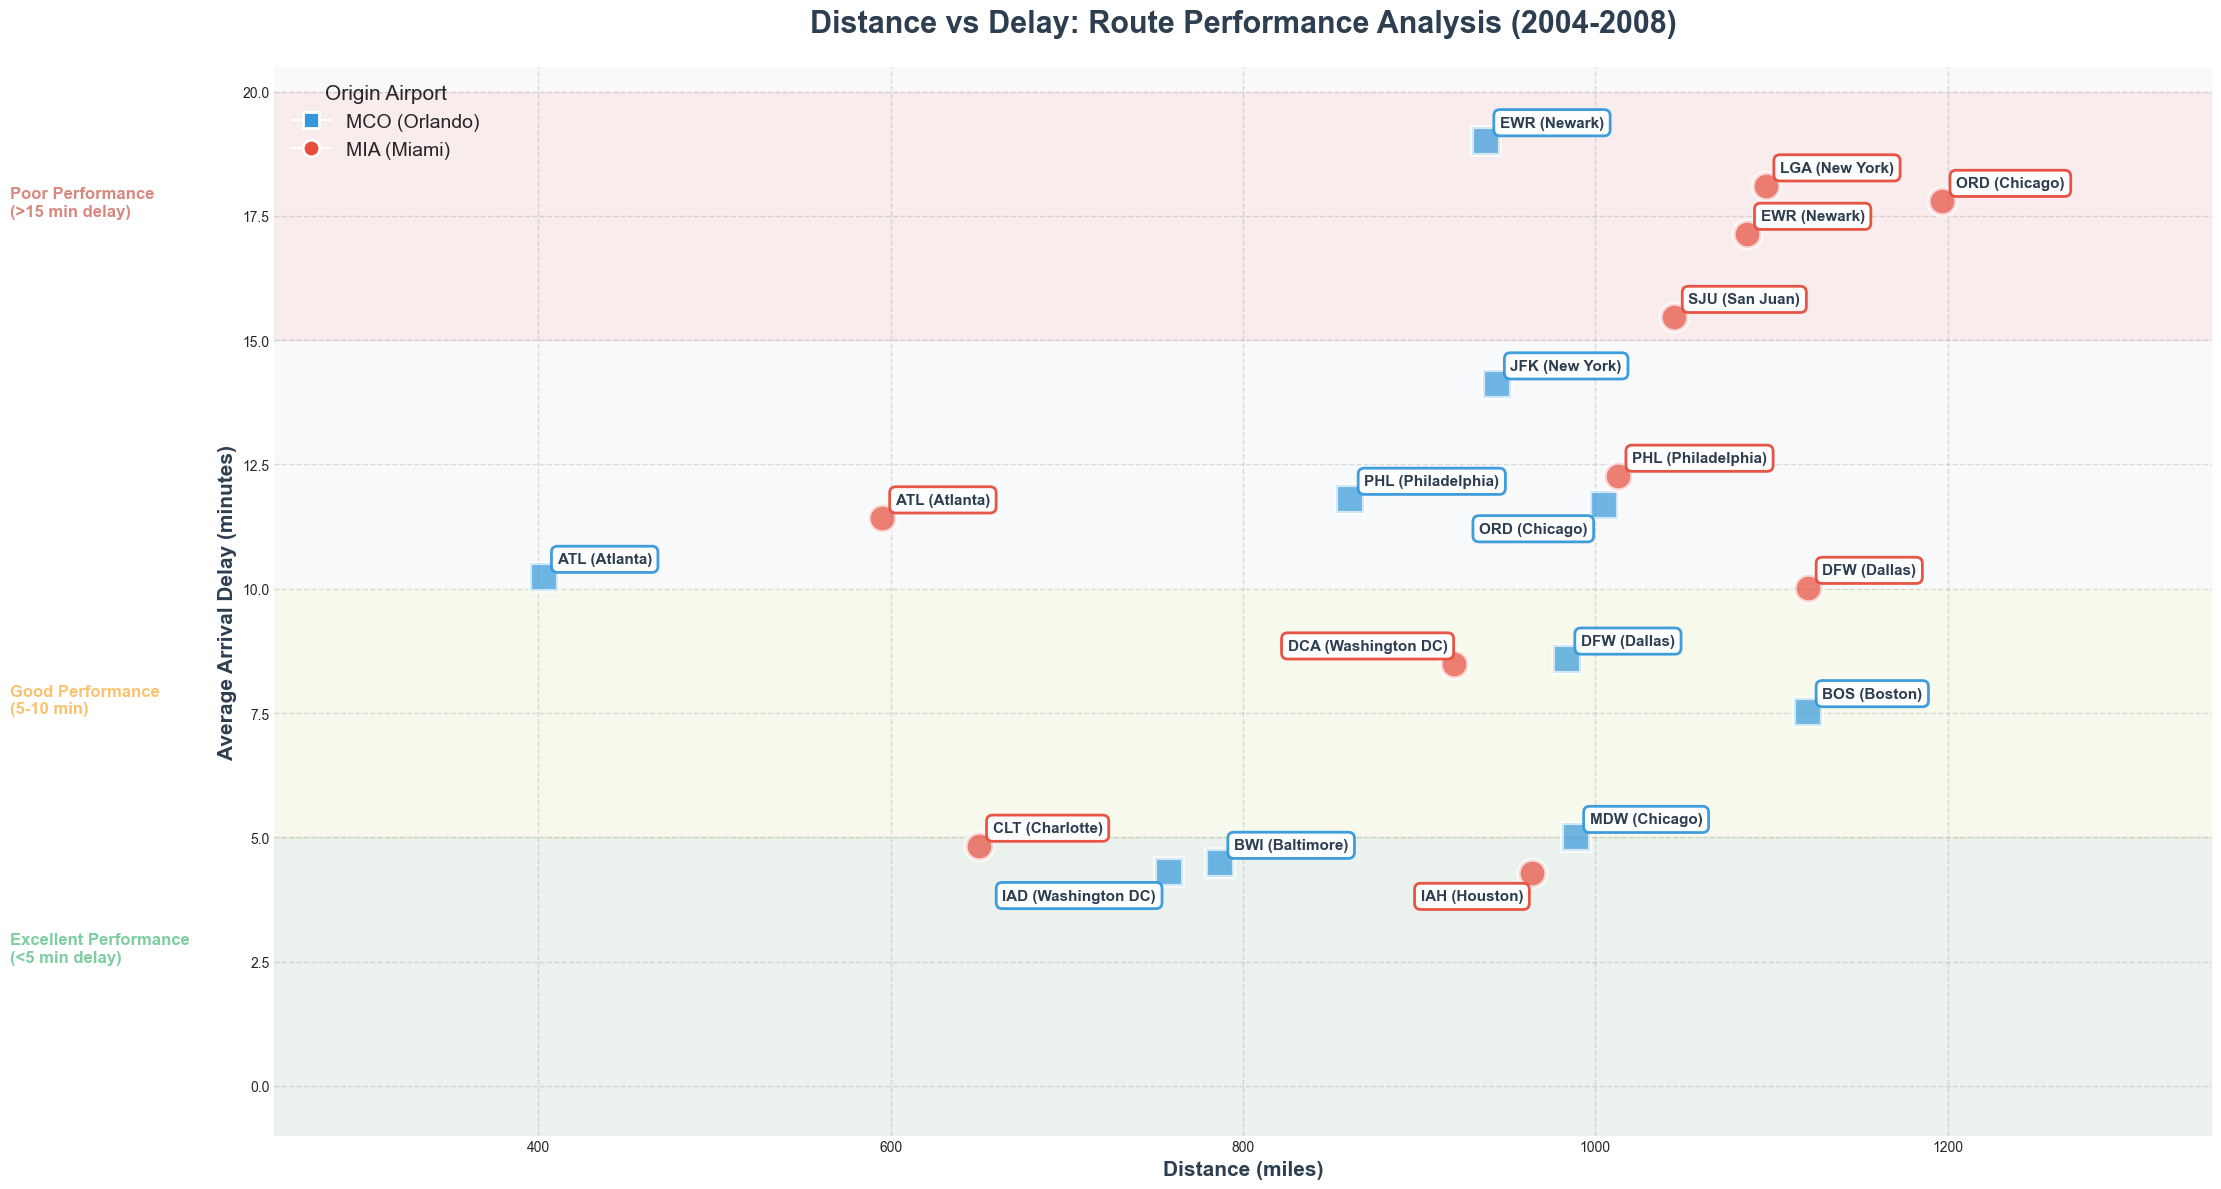

In [15]:
# PLOT 2: Distance vs Delay - Visualization (OPTIMIZED)
# Airport names mapping
airport_cities = {
    'ATL': 'Atlanta', 'PHL': 'Philadelphia', 'JFK': 'New York', 
    'BWI': 'Baltimore', 'EWR': 'Newark', 'DFW': 'Dallas',
    'ORD': 'Chicago', 'IAD': 'Washington DC', 'BOS': 'Boston',
    'CLT': 'Charlotte', 'LGA': 'New York', 'SJU': 'San Juan',
    'DCA': 'Washington DC', 'IAH': 'Houston', 'MDW': 'Chicago'
}

# Custom annotation offsets to avoid overlaps
# Custom annotation offsets to avoid overlaps
custom_offsets = {
    'MCO': {
        'IAD': (-120, -20),  # Κάτω αριστερά
        'ORD': (-90, -20)   # Κάτω αριστερά
    },
    'MIA': {
        'DCA': (-120, 10),   # Πάνω αριστερά
        'IAH': (-80, -20)   # Κάτω αριστερά
    }
}


fig, ax = plt.subplots(figsize=(22, 12))

# Plot both airports with different markers
for origin, data, marker in [('MCO', mco_top_dests, 's'), ('MIA', mia_top_dests, 'o')]:
    ax.scatter(data['Distance'], data['ArrDelay'], s=400, c=COLORS[origin],
               alpha=0.7, edgecolors='white', linewidth=3, marker=marker,
               label=f"{origin} ({'Orlando' if origin == 'MCO' else 'Miami'})", zorder=3)
    
    # Add annotations
    for _, row in data.iterrows():
        label = f"{row['Dest']} ({airport_cities.get(row['Dest'], '')})"
        offset = custom_offsets.get(origin, {}).get(row['Dest'], (10, 10))
        
        ax.annotate(label, xy=(row['Distance'], row['ArrDelay']), xytext=offset,
                   textcoords='offset points', fontsize=11, fontweight='bold',
                   color='#2c3e50', zorder=4,
                   bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                            edgecolor=COLORS[origin], alpha=0.95, linewidth=2))

# Performance zones with labels
zones = [
    (-2, 5, 'green', 2.5, 'Excellent Performance\n(<5 min delay)', '#27ae60'),
    (5, 10, 'yellow', 7.5, 'Good Performance\n(5-10 min)', '#f39c12'),
    (15, 20, 'red', 17.5, 'Poor Performance\n(>15 min delay)', '#c0392b')
]
for y_min, y_max, color, text_y, text, text_color in zones:
    ax.axhspan(y_min, y_max, color=color, alpha=0.05, zorder=0)
    ax.text(100, text_y, text, fontsize=12, color=text_color, 
           alpha=0.6, fontweight='bold')

# Styling
ax.set_xlabel('Distance (miles)', fontsize=15, fontweight='bold', color='#2c3e50')
ax.set_ylabel('Average Arrival Delay (minutes)', fontsize=15, fontweight='bold', color='#2c3e50')
ax.set_title('Distance vs Delay: Route Performance Analysis (2004-2008)',
            fontsize=22, fontweight='bold', pad=25, color='#2c3e50')
ax.set_ylim(-1, 20.5)
ax.set_xlim(250, 1350)

# Legend
from matplotlib.lines import Line2D
legend = ax.legend(handles=[
    Line2D([0], [0], marker='s', color='w', markerfacecolor=COLORS['MCO'], 
           markersize=12, label='MCO (Orlando)', markeredgewidth=2, markeredgecolor='white'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=COLORS['MIA'], 
           markersize=12, label='MIA (Miami)', markeredgewidth=2, markeredgecolor='white')
], loc='upper left', fontsize=14, framealpha=0.95, shadow=True, 
   title='Origin Airport', title_fontsize=15, fancybox=True)

ax.grid(True, alpha=0.25, linestyle='--', linewidth=1, color='gray')
ax.set_axisbelow(True)
ax.set_facecolor('#f8f9fa')

# Finalize and save plot
finalize_plot(fig, 'plot6.png')


### Plot 6: Distance vs On-Time Performance

**Overview:** Counterintuitive finding reveals longer flights demonstrate superior punctuality compared to short-haul operations.

**Key Findings:**
- **Short flights (<500mi) exhibit highest delays**: Northeast corridor congestion and hub saturation
- **Long flights (>1500mi) show better on-time performance**: Fewer intermediate stops, reduced exposure to cascading delays
- **Root causes**: Hub congestion management and quick-turnaround operational constraints
- Short-haul operations face cumulative delay propagation across multiple daily rotations
- Critical factors: Hub congestion management and operational efficiency at tight turnarounds

In [16]:
# Annual aggregations (exclude 2008 - incomplete data)
annual_growth = df[df['Year'].isin([2004, 2005, 2006, 2007])].groupby('Year').agg({
    'IsMCO': 'sum',
    'IsMIA': 'sum',
    'FlightNum': 'count'
}).reset_index()
annual_growth.columns = ['Year', 'MCO_Flights', 'MIA_Flights', 'Total_Flights']

# Calculate year-over-year growth rates
annual_growth['MCO_YoY'] = annual_growth['MCO_Flights'].pct_change() * 100
annual_growth['MIA_YoY'] = annual_growth['MIA_Flights'].pct_change() * 100

# Calculate market share
annual_growth['MCO_Share'] = (annual_growth['MCO_Flights'] / annual_growth['Total_Flights']) * 100
annual_growth['MIA_Share'] = (annual_growth['MIA_Flights'] / annual_growth['Total_Flights']) * 100

print("Annual Growth Data (2004-2007):")
print(annual_growth.to_string(index=False))
print("\nData preparation complete!")


Annual Growth Data (2004-2007):
 Year  MCO_Flights  MIA_Flights  Total_Flights  MCO_YoY   MIA_YoY  MCO_Share  MIA_Share
 2004       217525       130506         344250      NaN       NaN  63.188090  37.910240
 2005       237485       131505         364415 9.175957  0.765482  65.168832  36.086605
 2006       237826       132303         365595 0.143588  0.606821  65.051765  36.188405
 2007       259579       129496         384594 9.146603 -2.121645  67.494293  33.670832

Data preparation complete!


In [17]:
# Calculate DEPARTING flights (flights leaving FROM MCO/MIA)
departing_growth = df[df['Year'].isin([2004, 2005, 2006, 2007])].groupby('Year').agg({
    'Origin': lambda x: (x == 'MCO').sum(),  # Flights departing FROM MCO
}).reset_index()

# Add MIA departing flights
mia_departing = df[df['Year'].isin([2004, 2005, 2006, 2007])].groupby('Year').agg({
    'Origin': lambda x: (x == 'MIA').sum()  # Flights departing FROM MIA  
}).reset_index()

departing_growth['MCO_Departing'] = departing_growth['Origin']
departing_growth['MIA_Departing'] = mia_departing['Origin']
departing_growth = departing_growth.drop('Origin', axis=1)

# Calculate totals
departing_growth['Total_Departing'] = departing_growth['MCO_Departing'] + departing_growth['MIA_Departing']

# Calculate year-over-year growth
departing_growth['MCO_YoY_Dep'] = departing_growth['MCO_Departing'].pct_change() * 100
departing_growth['MIA_YoY_Dep'] = departing_growth['MIA_Departing'].pct_change() * 100

# Calculate market share
departing_growth['MCO_Share_Dep'] = (departing_growth['MCO_Departing'] / departing_growth['Total_Departing']) * 100
departing_growth['MIA_Share_Dep'] = (departing_growth['MIA_Departing'] / departing_growth['Total_Departing']) * 100

print("\nDeparting Flights Growth Data (2004-2007):")
print(departing_growth.to_string(index=False))

# Merge with arriving data for easy comparison
combined_growth = annual_growth.merge(departing_growth, on='Year', how='left')
print("\n✓ Combined arriving & departing data prepared!")


Departing Flights Growth Data (2004-2007):
 Year  MCO_Departing  MIA_Departing  Total_Departing  MCO_YoY_Dep  MIA_YoY_Dep  MCO_Share_Dep  MIA_Share_Dep
 2004         108762          65251           174013          NaN          NaN      62.502227      37.497773
 2005         118741          65743           184484     9.175080     0.754011      64.363847      35.636153
 2006         118910          66153           185063     0.142327     0.623641      64.253795      35.746205
 2007         129778          64742           194520     9.139685    -2.132934      66.717047      33.282953

✓ Combined arriving & departing data prepared!


### Visualization 7: Annual Growth Comparison

**What This Shows:**
- Left: Absolute flight volumes with YoY growth percentages
- Right: Market share evolution showing competitive positioning

**Data Period:** 2004-2007 (2008 excluded - incomplete)


✓ Saved: ../visualizations/plot7.png


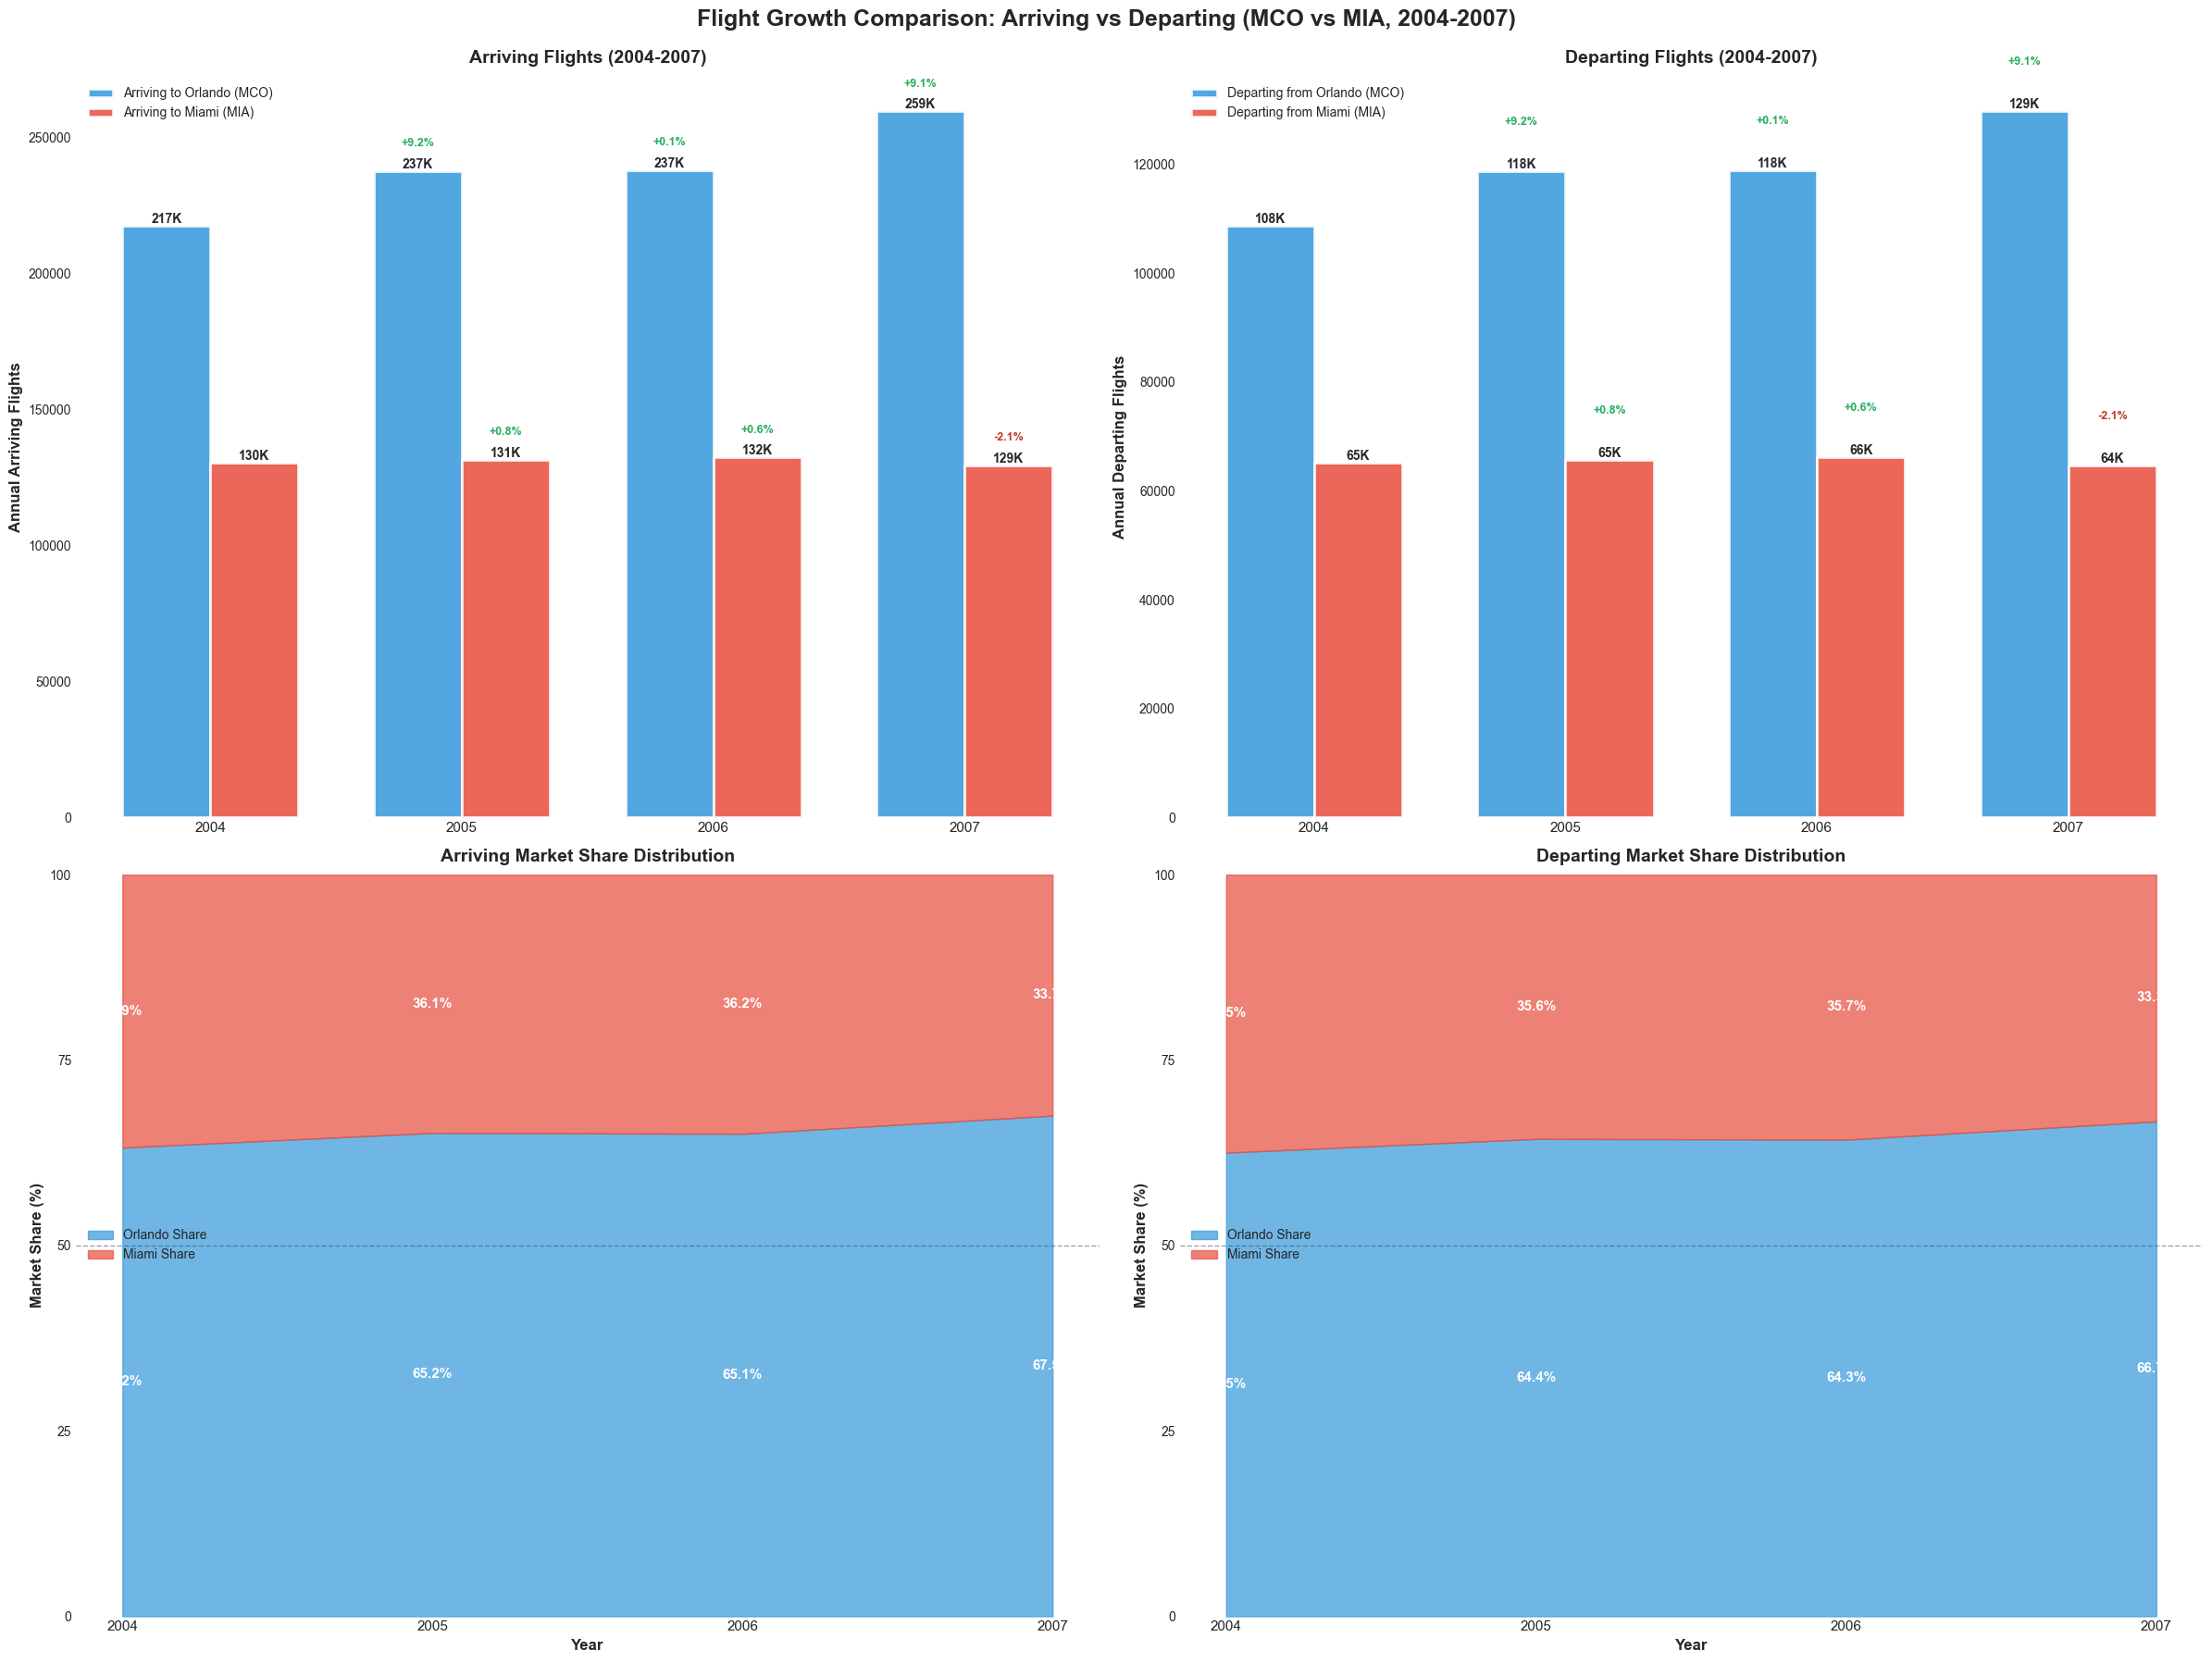

In [18]:
# Create comprehensive figure: Arriving vs Departing Flights (2x2)
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(24, 18))

# White backgrounds
for ax in [ax1, ax2, ax3, ax4]:
    ax.set_facecolor('white')
fig.patch.set_facecolor('white')

x_pos = np.arange(len(annual_growth))
bar_width = 0.35

# ============ TOP LEFT: ARRIVING FLIGHTS VOLUMES ============
bars_mco_arr = ax1.bar(x_pos - bar_width/2, annual_growth['MCO_Flights'],
                   bar_width, label='Arriving to Orlando (MCO)',
                   color='#3498db', alpha=0.85, edgecolor='white', linewidth=2)

bars_mia_arr = ax1.bar(x_pos + bar_width/2, annual_growth['MIA_Flights'],
                   bar_width, label='Arriving to Miami (MIA)',
                   color='#e74c3c', alpha=0.85, edgecolor='white', linewidth=2)

# Value labels
for bars in [bars_mco_arr, bars_mia_arr]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height/1000)}K',
                ha='center', va='bottom', fontsize=10, fontweight='semibold')


# Add YoY growth annotations for arriving
for i in range(1, len(annual_growth)):
    mco_growth = annual_growth.loc[i, 'MCO_YoY']
    mia_growth = annual_growth.loc[i, 'MIA_YoY']

    # MCO growth annotation
    y_mco = annual_growth.loc[i, 'MCO_Flights'] + 8000
    color_mco = '#27ae60' if mco_growth > 0 else '#c0392b'
    ax1.text(i - bar_width/2, y_mco, f'+{mco_growth:.1f}%',
             ha='center', va='bottom', fontsize=9, fontweight='bold',
             color=color_mco)

    # MIA growth annotation
    y_mia = annual_growth.loc[i, 'MIA_Flights'] + 8000
    color_mia = '#27ae60' if mia_growth > 0 else '#c0392b'
    ax1.text(i + bar_width/2, y_mia, f'{mia_growth:+.1f}%',
             ha='center', va='bottom', fontsize=9, fontweight='bold',
             color=color_mia)

ax1.set_title('Arriving Flights (2004-2007)', fontsize=14, fontweight='bold', pad=10)
ax1.set_ylabel('Annual Arriving Flights', fontsize=12, fontweight='semibold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(annual_growth['Year'].astype(int), fontsize=11)
ax1.grid(axis='y', alpha=0.2, linestyle='-', linewidth=0.5)
ax1.legend(loc='upper left', fontsize=10, framealpha=0.9, edgecolor='gray')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ============ TOP RIGHT: DEPARTING FLIGHTS VOLUMES ============
bars_mco_dep = ax2.bar(x_pos - bar_width/2, departing_growth['MCO_Departing'],
                   bar_width, label='Departing from Orlando (MCO)',
                   color='#3498db', alpha=0.85, edgecolor='white', linewidth=2)

bars_mia_dep = ax2.bar(x_pos + bar_width/2, departing_growth['MIA_Departing'],
                   bar_width, label='Departing from Miami (MIA)',
                   color='#e74c3c', alpha=0.85, edgecolor='white', linewidth=2)

# Value labels
for bars in [bars_mco_dep, bars_mia_dep]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height/1000)}K',
                ha='center', va='bottom', fontsize=10, fontweight='semibold')


# Add YoY growth annotations for departing
for i in range(1, len(departing_growth)):
    mco_growth = departing_growth.loc[i, 'MCO_YoY_Dep']
    mia_growth = departing_growth.loc[i, 'MIA_YoY_Dep']

    # MCO growth annotation
    y_mco = departing_growth.loc[i, 'MCO_Departing'] + 8000
    color_mco = '#27ae60' if mco_growth > 0 else '#c0392b'
    ax2.text(i - bar_width/2, y_mco, f'+{mco_growth:.1f}%',
             ha='center', va='bottom', fontsize=9, fontweight='bold',
             color=color_mco)

    # MIA growth annotation
    y_mia = departing_growth.loc[i, 'MIA_Departing'] + 8000
    color_mia = '#27ae60' if mia_growth > 0 else '#c0392b'
    ax2.text(i + bar_width/2, y_mia, f'{mia_growth:+.1f}%',
             ha='center', va='bottom', fontsize=9, fontweight='bold',
             color=color_mia)

ax2.set_title('Departing Flights (2004-2007)', fontsize=14, fontweight='bold', pad=10)
ax2.set_ylabel('Annual Departing Flights', fontsize=12, fontweight='semibold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(annual_growth['Year'].astype(int), fontsize=11)
ax2.grid(axis='y', alpha=0.2, linestyle='-', linewidth=0.5)
ax2.legend(loc='upper left', fontsize=10, framealpha=0.9, edgecolor='gray')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ============ BOTTOM LEFT: ARRIVING MARKET SHARE (STACKED AREA) ============
years = annual_growth['Year'].values
mco_share = annual_growth['MCO_Share'].values
mia_share = annual_growth['MIA_Share'].values

# Stacked area chart
ax3.fill_between(years, 0, mco_share,
                 color='#3498db', alpha=0.7, label='Orlando Share')
ax3.fill_between(years, mco_share, 100,
                 color='#e74c3c', alpha=0.7, label='Miami Share')

# Add a thin line at 50% for reference
ax3.axhline(y=50, color='#34495e', linestyle='--', linewidth=1, alpha=0.5, zorder=5)

# Add percentage labels in the middle of each area
for i, year in enumerate(years):
    # MCO label (in the middle of its area)
    mco_mid = mco_share[i] / 2
    ax3.text(year, mco_mid, f"{mco_share[i]:.1f}%",
             ha='center', va='center', fontsize=11, fontweight='bold',
             color='white', zorder=10)

    # MIA label (in the middle of its area)
    mia_mid = mco_share[i] + (100 - mco_share[i]) / 2
    ax3.text(year, mia_mid, f"{mia_share[i]:.1f}%",
             ha='center', va='center', fontsize=11, fontweight='bold',
             color='white', zorder=10)

ax3.set_title('Arriving Market Share Distribution', fontsize=14, fontweight='bold', pad=10)
ax3.set_xlabel('Year', fontsize=12, fontweight='semibold')
ax3.set_ylabel('Market Share (%)', fontsize=12, fontweight='semibold')
ax3.set_xticks(years)
ax3.set_xticklabels(years.astype(int), fontsize=11)
ax3.set_ylim(0, 100)
ax3.set_yticks([0, 25, 50, 75, 100])
ax3.legend(loc='center left', fontsize=10, framealpha=0.9, edgecolor='gray')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.grid(axis='y', alpha=0.2, linestyle='-', linewidth=0.5)

# ============ BOTTOM RIGHT: DEPARTING MARKET SHARE (STACKED AREA) ============
years_dep = departing_growth['Year'].values
mco_share_dep = departing_growth['MCO_Share_Dep'].values
mia_share_dep = departing_growth['MIA_Share_Dep'].values

# Stacked area chart
ax4.fill_between(years_dep, 0, mco_share_dep,
                 color='#3498db', alpha=0.7, label='Orlando Share')
ax4.fill_between(years_dep, mco_share_dep, 100,
                 color='#e74c3c', alpha=0.7, label='Miami Share')

# Add a thin line at 50% for reference
ax4.axhline(y=50, color='#34495e', linestyle='--', linewidth=1, alpha=0.5, zorder=5)

# Add percentage labels
for i, year in enumerate(years_dep):
    # MCO label
    mco_mid = mco_share_dep[i] / 2
    ax4.text(year, mco_mid, f"{mco_share_dep[i]:.1f}%",
             ha='center', va='center', fontsize=11, fontweight='bold',
             color='white', zorder=10)

    # MIA label
    mia_mid = mco_share_dep[i] + (100 - mco_share_dep[i]) / 2
    ax4.text(year, mia_mid, f"{mia_share_dep[i]:.1f}%",
             ha='center', va='center', fontsize=11, fontweight='bold',
             color='white', zorder=10)

ax4.set_title('Departing Market Share Distribution', fontsize=14, fontweight='bold', pad=10)
ax4.set_xlabel('Year', fontsize=12, fontweight='semibold')
ax4.set_ylabel('Market Share (%)', fontsize=12, fontweight='semibold')
ax4.set_xticks(years_dep)
ax4.set_xticklabels(years_dep.astype(int), fontsize=11)
ax4.set_ylim(0, 100)
ax4.set_yticks([0, 25, 50, 75, 100])
ax4.legend(loc='center left', fontsize=10, framealpha=0.9, edgecolor='gray')
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.grid(axis='y', alpha=0.2, linestyle='-', linewidth=0.5)

# Overall title
fig.suptitle('Flight Growth Comparison: Arriving vs Departing (MCO vs MIA, 2004-2007)',
             fontsize=18, fontweight='bold', y=0.995)

plt.tight_layout()

# Finalize and save plot
finalize_plot(fig, 'plot7.png')


### Plot 7: Airport Growth Trajectories (2004-2008)

**Overview:** Divergent growth patterns reveal fundamental differences in market dynamics between MCO and MIA.

**Key Findings:**
- **MCO explosive growth**: Approximately 25% increase from 2004 to 2007
- **MIA stability**: Minimal growth, consistent with mature hub market saturation
- **2008 recession impact**: Sharp traffic declines at both airports following financial crisis
- MCO growth driven by expanding theme park tourism and low-cost carrier market entry
- MIA's mature market dynamics limit capacity for organic growth within existing hub structure

In [19]:
# Get top 5 carriers by total flights (exclude 2008 - incomplete)
carrier_totals = df[df['Year'].isin([2004, 2005, 2006, 2007])].groupby('UniqueCarrier').size().sort_values(ascending=False)
top_5_carriers = carrier_totals.head(5).index.tolist()

print("Top 5 Carriers by Total Flights (2004-2007):")
for carrier in top_5_carriers:
    print(f"  {carrier}: {carrier_totals[carrier]:,} flights")

# 2007 market share (for pie charts)
market_share_2007 = df[df['Year'] == 2007].groupby('UniqueCarrier').size().sort_values(ascending=False)
top_5_2007 = market_share_2007[top_5_carriers].sum()
others_2007 = market_share_2007.sum() - top_5_2007

print(f"\n2007 Market Share:")
print(f"  Top 5: {(top_5_2007 / market_share_2007.sum() * 100):.1f}%")
print(f"  Others: {(others_2007 / market_share_2007.sum() * 100):.1f}%")

# Split by airport for pie charts
mco_2007 = df[(df['Year'] == 2007) & (df['IsMCO'] == 1)].groupby('UniqueCarrier').size().sort_values(ascending=False)
mia_2007 = df[(df['Year'] == 2007) & (df['IsMIA'] == 1)].groupby('UniqueCarrier').size().sort_values(ascending=False)

# Evolution over time (for stacked bars)
carrier_evolution = df[df['Year'].isin([2004, 2005, 2006, 2007])].groupby(['Year', 'UniqueCarrier']).size().unstack(fill_value=0)
carrier_evolution_top5 = carrier_evolution[top_5_carriers] if all(c in carrier_evolution.columns for c in top_5_carriers) else pd.DataFrame()

# Add "Others" category
carrier_evolution_top5['Others'] = df[df['Year'].isin([2004, 2005, 2006, 2007])].groupby('Year').size() - carrier_evolution_top5.sum(axis=1)

print("\nCarrier Evolution (2004-2007):")
print(carrier_evolution_top5)


Top 5 Carriers by Total Flights (2004-2007):
  AA: 400,741 flights
  WN: 257,915 flights
  DL: 150,331 flights
  FL: 124,778 flights
  US: 110,916 flights

2007 Market Share:
  Top 5: 73.4%
  Others: 26.6%

Carrier Evolution (2004-2007):
UniqueCarrier      AA     WN     DL     FL     US  Others
Year                                                     
2004           102212  50184  41734  21443  27679  100998
2005           100378  61187  38975  27040  27857  108978
2006           100415  67143  34449  33351  28434  101803
2007            97736  79401  35173  42944  26946  102394


In [20]:
# Calculate carrier market share for ALL years (2004-2007)
years = [2004, 2005, 2006, 2007]

# For MCO
mco_by_year = {}
for year in years:
    mco_year = df[(df['Year'] == year) & (df['IsMCO'] == 1)].groupby('UniqueCarrier').size().sort_values(ascending=False)
    total = mco_year.sum()
    mco_pct = (mco_year / total * 100).round(1)
    mco_by_year[year] = mco_pct

# For MIA
mia_by_year = {}
for year in years:
    mia_year = df[(df['Year'] == year) & (df['IsMIA'] == 1)].groupby('UniqueCarrier').size().sort_values(ascending=False)
    total = mia_year.sum()
    mia_pct = (mia_year / total * 100).round(1)
    mia_by_year[year] = mia_pct

print("✓ Carrier market share calculated for 2004-2007")
print(f"  MCO carriers per year: {[len(mco_by_year[y]) for y in years]}")
print(f"  MIA carriers per year: {[len(mia_by_year[y]) for y in years]}")

✓ Carrier market share calculated for 2004-2007
  MCO carriers per year: [16, 18, 16, 14]
  MIA carriers per year: [13, 13, 11, 11]


## Enhanced Carrier Market Share Visualization (2004-2007)

The following cells create improved visualizations for MCO (Orlando) and MIA (Miami) airports:

- **Top 4 carriers** shown in horizontal stacked bars with enhanced color distinction
- **"Others" breakdown** displayed in pie charts below each year
- **Patterns and borders** added for better accessibility (colorblind-friendly, B&W printing)
- **Separate plots** for MCO ([plot8.png](../plots/plot8.png)) and MIA ([plot9.png](../plots/plot9.png))

In [21]:
# ============================================================================
# Data Processing for Enhanced Carrier Market Share Visualization
# ============================================================================

TOP_N = 4
years = [2004, 2005, 2006, 2007]

# Collect 'Others' breakdown for both airports (carriers with ≥1% market share)
mco_others_detail = {}
mia_others_detail = {}

for year in years:
    # MCO Others breakdown
    top_4_mco = mco_by_year[year].head(TOP_N).index
    others_mco = mco_by_year[year][~mco_by_year[year].index.isin(top_4_mco)]
    mco_others_detail[year] = others_mco[others_mco >= 1.0].sort_values(ascending=False)
    
    # MIA Others breakdown
    top_4_mia = mia_by_year[year].head(TOP_N).index
    others_mia = mia_by_year[year][~mia_by_year[year].index.isin(top_4_mia)]
    mia_others_detail[year] = others_mia[others_mia >= 1.0].sort_values(ascending=False)

✓ Saved: ../visualizations/plot8.png


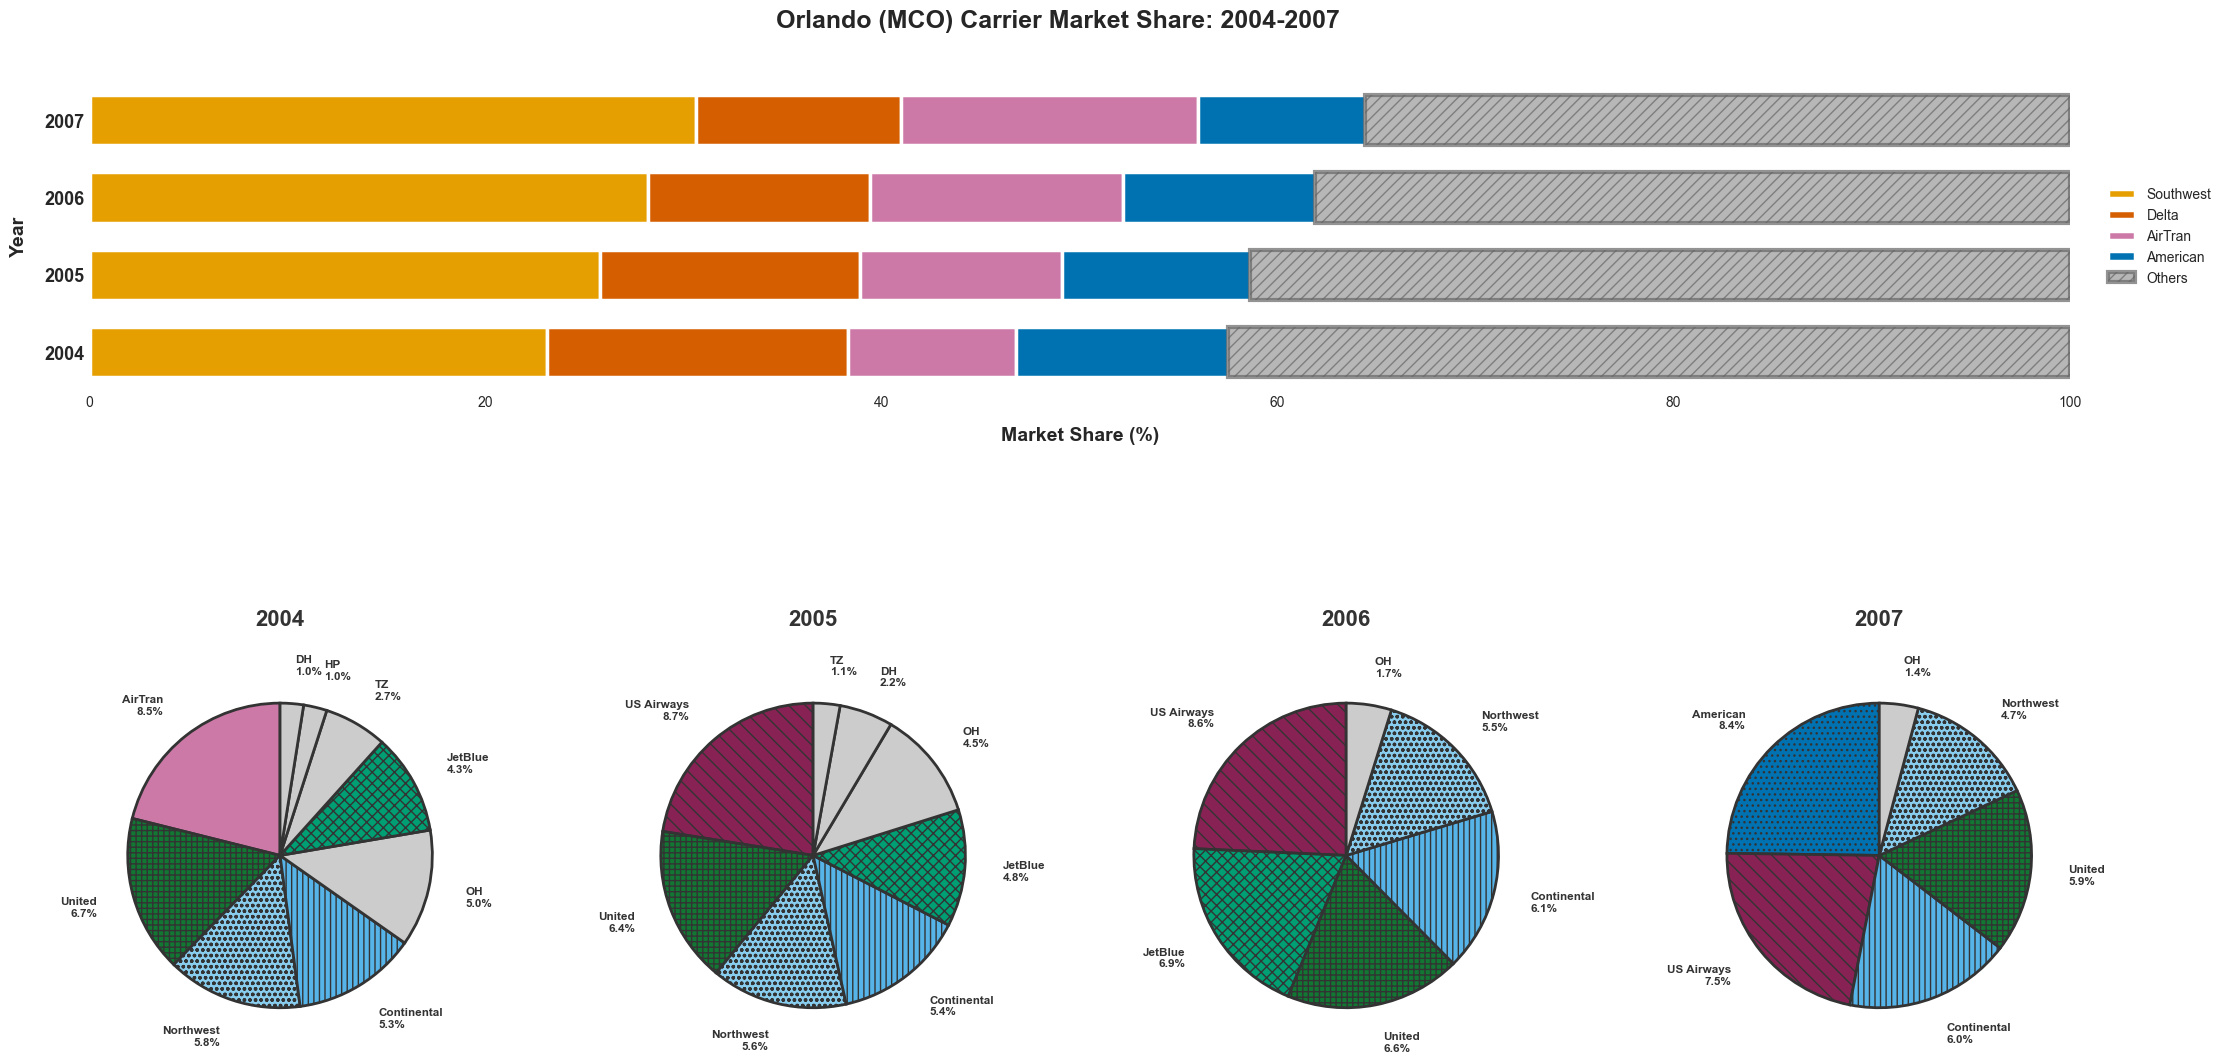

In [22]:
# ============================================================================
# MCO (Orlando) Carrier Market Share Visualization
# ============================================================================

from matplotlib.gridspec import GridSpec

years = [2004, 2005, 2006, 2007]

# Enhanced color scheme with better contrast
carrier_colors = {
    'WN': '#E69F00',   # Southwest - Orange
    'AA': '#0072B2',   # American - Blue
    'DL': '#D55E00',   # Delta - Vermillion
    'B6': '#009E73',   # JetBlue - Bluish green
    'FL': '#CC79A7',   # AirTran - Reddish purple
    'CO': '#56B4E9',   # Continental - Sky blue
    'XE': '#F0E442',   # Envoy Air - Yellow
    'US': '#882255',   # US Airways - Purple
    'MQ': '#44AA99',   # ExpressJet - Green-blue
    'NW': '#88CCEE',   # Northwest - Cyan
    'UA': '#117733',   # United - Dark green
    'Others': '#999999' # Gray
}

# Unique patterns for better distinction
carrier_patterns = {
    'WN': '',      # Southwest - solid
    'AA': '...',   # American - dots
    'DL': '///',   # Delta - diagonal lines
    'B6': 'xxx',   # JetBlue - crosshatch
    'FL': '',      # AirTran - solid
    'CO': '|||',   # Continental - vertical lines
    'XE': '',      # Envoy Air - solid
    'US': '\\\\', # US Airways - reverse diagonal
    'MQ': '---',   # ExpressJet - horizontal lines
    'NW': 'ooo',   # Northwest - circles
    'UA': '+++',   # United - plus signs
    'Others': '///' # Gray with diagonal
}

carrier_names = {
    'WN': 'Southwest', 'AA': 'American', 'DL': 'Delta',
    'B6': 'JetBlue', 'FL': 'AirTran', 'CO': 'Continental',
    'XE': 'Envoy Air', 'US': 'US Airways', 'MQ': 'ExpressJet',
    'NW': 'Northwest', 'UA': 'United', 'Others': 'Others'
}

# Create MCO figure
fig_mco = plt.figure(figsize=(22, 12))
gs_mco = GridSpec(2, 4, figure=fig_mco, height_ratios=[1.5, 2.5], 
                  hspace=0.5, wspace=0.4,
                  left=0.06, right=0.96, top=0.91, bottom=0.05)

# Main bars subplot
ax_mco_bars = fig_mco.add_subplot(gs_mco[0, :])
ax_mco_bars.set_facecolor('white')

# Calculate top 4 carriers for MCO
all_mco = pd.concat([mco_by_year[y].head(4) for y in years])
top_4_overall_mco = all_mco.groupby(level=0).sum().sort_values(ascending=False).head(4).index

# Build stacked bar data
mco_stacked_data = {carrier: [] for carrier in top_4_overall_mco}
mco_stacked_data['Others'] = []

for year in years:
    for carrier in top_4_overall_mco:
        value = mco_by_year[year].get(carrier, 0)
        mco_stacked_data[carrier].append(value)
    
    top_4_sum = sum(mco_stacked_data[c][-1] for c in top_4_overall_mco)
    mco_stacked_data['Others'].append(100 - top_4_sum)

# Draw horizontal stacked bars
y_positions = np.arange(len(years))
left = np.zeros(len(years))

for carrier in top_4_overall_mco:
    values = mco_stacked_data[carrier]
    ax_mco_bars.barh(y_positions, values, left=left, height=0.65,
                     label=carrier_names.get(carrier, carrier),
                     color=carrier_colors.get(carrier, '#CCCCCC'),
                     edgecolor='white', linewidth=2.5)
    left += values

# Others segment
ax_mco_bars.barh(y_positions, mco_stacked_data['Others'], left=left, height=0.65,
                 label='Others', color=carrier_colors['Others'],
                 edgecolor='#666', linewidth=3,
                 hatch='///', alpha=0.7)

# Bars styling
ax_mco_bars.set_yticks(y_positions)
ax_mco_bars.set_yticklabels(years, fontsize=13, fontweight='bold')
ax_mco_bars.set_xlabel('Market Share (%)', fontsize=14, fontweight='bold', labelpad=12)
ax_mco_bars.set_ylabel('Year', fontsize=14, fontweight='bold', labelpad=12)
ax_mco_bars.set_xlim(0, 100)
ax_mco_bars.set_ylim(-0.5, len(years) - 0.5)
ax_mco_bars.spines['top'].set_visible(False)
ax_mco_bars.spines['right'].set_visible(False)
ax_mco_bars.grid(axis='x', alpha=0.3, linestyle='-', linewidth=0.8)
ax_mco_bars.legend(loc='center left', fontsize=10, framealpha=0.98, 
                   edgecolor='#666', ncol=1, borderpad=0.8,
                   bbox_to_anchor=(1.01, 0.5))

# 'Others' breakdown pie charts
for idx, year in enumerate(years):
    ax_pie = fig_mco.add_subplot(gs_mco[1, idx])
    ax_pie.set_facecolor('#F0F0F0')
    
    others_data = mco_others_detail[year]
    
    if len(others_data) > 0:
        colors = [carrier_colors.get(c, '#CCCCCC') for c in others_data.index]
        patterns = [carrier_patterns.get(c, '') for c in others_data.index]
        
        wedges, texts = ax_pie.pie(others_data.values, 
                                    colors=colors,
                                    startangle=90,
                                    wedgeprops=dict(edgecolor='#333', linewidth=2))
        
        for wedge, pattern in zip(wedges, patterns):
            if pattern:
                wedge.set_hatch(pattern)
        
        for wedge, carrier, value in zip(wedges, others_data.index, others_data.values):
            ang = (wedge.theta2 - wedge.theta1) / 2.0 + wedge.theta1
            x = np.cos(np.deg2rad(ang))
            y = np.sin(np.deg2rad(ang))
            
            ha = {-1: "right", 1: "left"}[int(np.sign(x))]
            
            ax_pie.text(x * 1.25, y * 1.25, 
                       f"{carrier_names.get(carrier, carrier)}\n{value:.1f}%", 
                       ha=ha, va='center',
                       fontsize=8.5, fontweight='semibold',
                       color='#333')
        
        ax_pie.text(0, 1.55, f'{year}', 
                   ha='center', va='center',
                   fontsize=16, fontweight='bold', color='#333',
                   transform=ax_pie.transData)
    else:
        ax_pie.text(0.5, 0.5, 'N/A', ha='center', va='center',
                   fontsize=11, color='gray', transform=ax_pie.transAxes)
        ax_pie.axis('off')

fig_mco.patch.set_facecolor('white')
fig_mco.text(0.5, 0.97, 'Orlando (MCO) Carrier Market Share: 2004-2007',
            ha='center', va='top', fontsize=18, fontweight='bold')
finalize_plot(fig_mco, 'plot8.png')

### Plot 8: MCO Carrier Market Share Evolution (2004-2007)

**Overview:** Orlando market exhibits tourism-driven competitive structure with significant low-cost carrier presence.

**Key Findings:**
- **Top 4 carriers** visualized with horizontal stacked bars; "Others" breakdown shown in pie charts per year
- **Low-cost carrier dominance**: Southwest and AirTran command majority market share
- **Fragmented "Others" segment**: Multiple regional carriers maintain 1-5% market shares
- **Market accessibility**: Relatively low barriers to entry indicated by competitive fragmentation
- **Visual design**: Enhanced with patterns and borders for colorblind accessibility and B&W printing

✓ Saved: ../visualizations/plot9.png


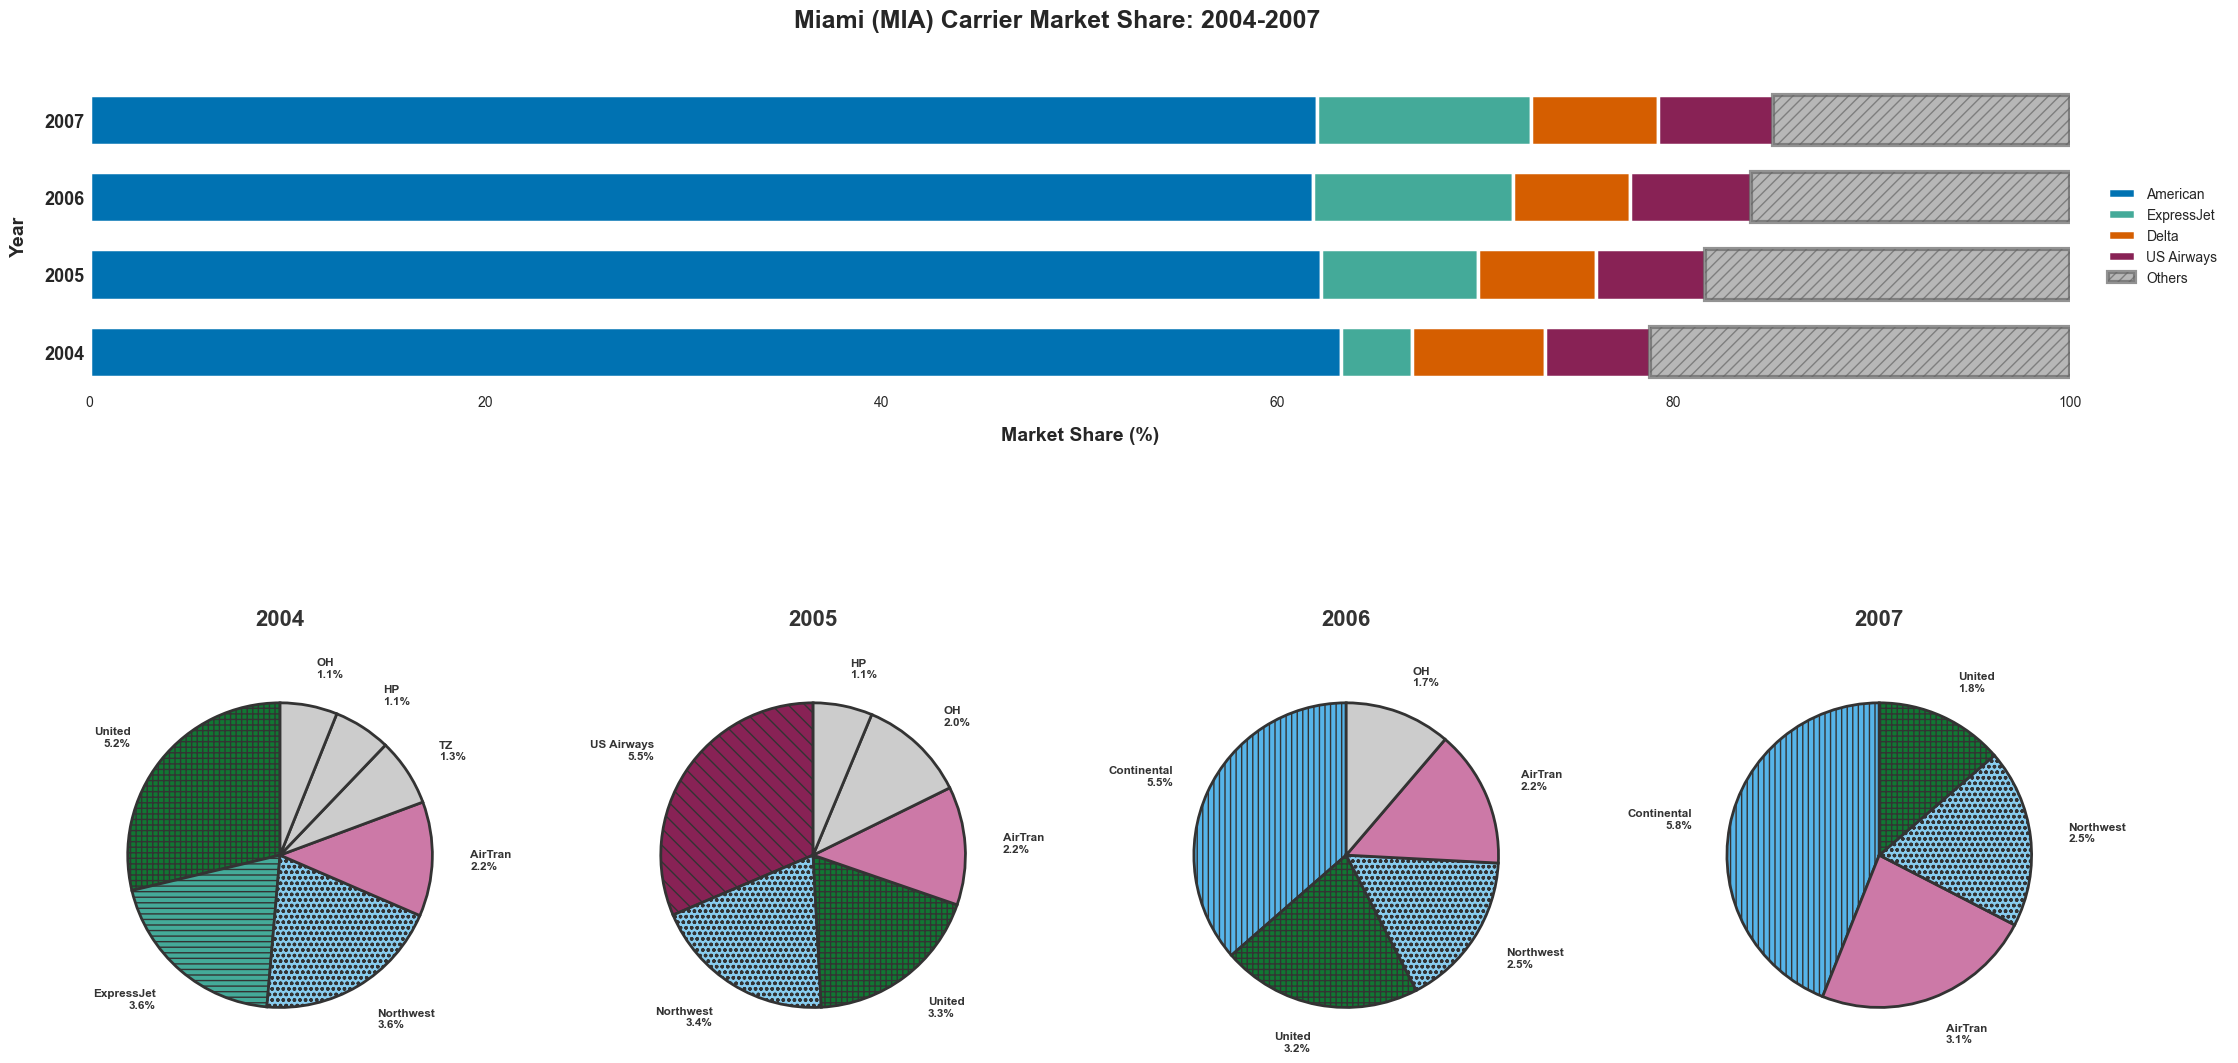

In [23]:
# ============================================================================
# MIA (Miami) Carrier Market Share Visualization
# ============================================================================

# Create MIA figure
fig_mia = plt.figure(figsize=(22, 12))
gs_mia = GridSpec(2, 4, figure=fig_mia, height_ratios=[1.5, 2.5], 
                  hspace=0.5, wspace=0.4,
                  left=0.06, right=0.96, top=0.91, bottom=0.05)

# Main bars subplot
ax_mia_bars = fig_mia.add_subplot(gs_mia[0, :])
ax_mia_bars.set_facecolor('white')

# Calculate top 4 carriers for MIA
all_mia = pd.concat([mia_by_year[y].head(4) for y in years])
top_4_overall_mia = all_mia.groupby(level=0).sum().sort_values(ascending=False).head(4).index

# Build stacked bar data
mia_stacked_data = {carrier: [] for carrier in top_4_overall_mia}
mia_stacked_data['Others'] = []

for year in years:
    for carrier in top_4_overall_mia:
        value = mia_by_year[year].get(carrier, 0)
        mia_stacked_data[carrier].append(value)
    
    top_4_sum = sum(mia_stacked_data[c][-1] for c in top_4_overall_mia)
    mia_stacked_data['Others'].append(100 - top_4_sum)

# Draw horizontal stacked bars
y_positions = np.arange(len(years))
left = np.zeros(len(years))

for carrier in top_4_overall_mia:
    values = mia_stacked_data[carrier]
    ax_mia_bars.barh(y_positions, values, left=left, height=0.65,
                     label=carrier_names.get(carrier, carrier),
                     color=carrier_colors.get(carrier, '#CCCCCC'),
                     edgecolor='white', linewidth=2.5)
    left += values

# Others segment
ax_mia_bars.barh(y_positions, mia_stacked_data['Others'], left=left, height=0.65,
                 label='Others', color=carrier_colors['Others'],
                 edgecolor='#666', linewidth=3,
                 hatch='///', alpha=0.7)

# Bars styling
ax_mia_bars.set_yticks(y_positions)
ax_mia_bars.set_yticklabels(years, fontsize=13, fontweight='bold')
ax_mia_bars.set_xlabel('Market Share (%)', fontsize=14, fontweight='bold', labelpad=12)
ax_mia_bars.set_ylabel('Year', fontsize=14, fontweight='bold', labelpad=12)
ax_mia_bars.set_xlim(0, 100)
ax_mia_bars.set_ylim(-0.5, len(years) - 0.5)
ax_mia_bars.spines['top'].set_visible(False)
ax_mia_bars.spines['right'].set_visible(False)
ax_mia_bars.grid(axis='x', alpha=0.3, linestyle='-', linewidth=0.8)
ax_mia_bars.legend(loc='center left', fontsize=10, framealpha=0.98, 
                   edgecolor='#666', ncol=1, borderpad=0.8,
                   bbox_to_anchor=(1.01, 0.5))

# 'Others' breakdown pie charts
for idx, year in enumerate(years):
    ax_pie = fig_mia.add_subplot(gs_mia[1, idx])
    ax_pie.set_facecolor('#F0F0F0')
    
    others_data = mia_others_detail[year]
    
    if len(others_data) > 0:
        colors = [carrier_colors.get(c, '#CCCCCC') for c in others_data.index]
        patterns = [carrier_patterns.get(c, '') for c in others_data.index]
        
        wedges, texts = ax_pie.pie(others_data.values, 
                                    colors=colors,
                                    startangle=90,
                                    wedgeprops=dict(edgecolor='#333', linewidth=2))
        
        for wedge, pattern in zip(wedges, patterns):
            if pattern:
                wedge.set_hatch(pattern)
        
        for wedge, carrier, value in zip(wedges, others_data.index, others_data.values):
            ang = (wedge.theta2 - wedge.theta1) / 2.0 + wedge.theta1
            x = np.cos(np.deg2rad(ang))
            y = np.sin(np.deg2rad(ang))
            
            ha = {-1: "right", 1: "left"}[int(np.sign(x))]
            
            ax_pie.text(x * 1.25, y * 1.25, 
                       f"{carrier_names.get(carrier, carrier)}\n{value:.1f}%", 
                       ha=ha, va='center',
                       fontsize=8.5, fontweight='semibold',
                       color='#333')
        
        ax_pie.text(0, 1.55, f'{year}', 
                   ha='center', va='center',
                   fontsize=16, fontweight='bold', color='#333',
                   transform=ax_pie.transData)
    else:
        ax_pie.text(0.5, 0.5, 'N/A', ha='center', va='center',
                   fontsize=11, color='gray', transform=ax_pie.transAxes)
        ax_pie.axis('off')

fig_mia.patch.set_facecolor('white')
fig_mia.text(0.5, 0.97, 'Miami (MIA) Carrier Market Share: 2004-2007',
            ha='center', va='top', fontsize=18, fontweight='bold')
finalize_plot(fig_mia, 'plot9.png')

### Plot 9: MIA Carrier Market Share Evolution (2004-2007)

**Overview:** Miami demonstrates hub-dominated market structure with significantly higher concentration than MCO.

**Key Findings:**
- **American Airlines dominance**: MIA serves as primary hub for Latin American operations
- **High market concentration**: Top 4 carriers control larger combined share than MCO equivalents
- **Reduced "Others" segment**: Indicates higher barriers to entry in hub-dominated markets
- **Structural contrast with MCO**: Leisure destination (competitive) vs international hub (concentrated)
- **Strategic implications**: Airport functional role fundamentally shapes competitive market dynamics